Task S: HAM10000 (Skin Cancer MNIST) Dataset
7-class skin lesion classification (~10,015 images)
Dataset: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
Preprocessed: https://www.kaggle.com/datasets/rayeedaabir/ham10000-preprocessed

Continuous Learning pipeline — all 12 architectures:
  9 original CNNs (ResNet-18/50/101/152, VGG-11/16/19, AlexNet, GoogLeNet)
  Swin Transformer | CoAtNet | KAN

Each model is loaded from its Task D final checkpoint (final_cl_model_taskD_{model}.pth),
which already knows Tasks A+B+C+D. Task S teaches 7 new skin lesion classes while
rehearsing all four prior tasks.

NOTE: Task S adds 7 genuinely new classes not seen in A–D:
  Actinic Keratoses | Basal Cell Carcinoma | Benign Keratosis | Dermatofibroma
  Melanoma | Melanocytic Nevi | Vascular Lesions
The unified class space therefore grows beyond Task D's size.

BATCH_SIZE kept at 16. Rehearsal batch = BATCH_SIZE // 4 per buffer (A, B, C, D).
Total per-step batch: 16 (new Task S) + 4 (A) + 4 (B) + 4 (C) + 4 (D) = 32.

V1: 11 CNNs + Transformers (no KAN). Upload final_cl_model_taskD_*.pth as a dataset.
V2: Uncomment "kan" in MODELS_TO_TEST and update the dataset with KAN weights.

Each model runs:
  1. Naive Fine-tuning  — no memory, shows cumulative forgetting of A, B, C, D
  2. Rehearsal CL       — 10% from each of Tasks A, B, C, D buffer each epoch

Per-epoch results printed in full detail and saved to CSV after every epoch.

Total datasets:
  1) Task-A: Custom Dataset (4-class, ~14k images)
  2) Task-B: ODIR Dataset (8-class ocular disease)
  3) Task-C: Eye Diseases Classification (4-class, ~4.2k images)
  4) Task-D: LAG Database (binary glaucoma)
  5) Task-S: HAM10000 (7-class skin lesion)

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "timm", "--upgrade", "-q"], check=True)
subprocess.run(["pip", "install", "pykan", "-q"], check=True)
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="kan")
print("timm and pykan ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.9 MB/s eta 0:00:00
timm and pykan ready


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import copy
import json
import os
import random
import shutil
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from IPython.display import FileLink, display
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import ConcatDataset, DataLoader, Subset
from torchvision import datasets, models

print(f"PyTorch: {torch.__version__} | Torchvision: {torchvision.__version__}")

# ── Configuration ─────────────────────────────────────────────────────────────
RANDOM_SEED                 = 42
DEVICE                      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE                  = 16
CONTINUOUS_EPOCHS           = 15
CONTINUOUS_LEARNING_RATE    = 0.0001
REHEARSAL_BUFFER_PERCENTAGE = 0.10  # 10% each from Tasks A, B, C, D

# ── Paths ─────────────────────────────────────────────────────────────────────
# Task D final models — upload final_cl_model_taskD_*.pth files as a Kaggle dataset
EXPERT_ABCD_MODELS_DIR  = "/kaggle/input/datasets/rayeedaabir/task-d-model-paths"
TASK_A_DATA_DIR         = "/kaggle/input/datasets/rayeedaabir/custom-dataset/Custom Dataset (4-class)"
TASK_C_DATA_DIR         = "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset"
TASK_D_DATA_DIR         = "/kaggle/input/datasets/rayeedaabir/lag-database-part1-uk/LAG_database_part1_UK"
# Both ODIR and HAM10000 come from the same preprocessed dataset
TASK_B_PREPROCESSED_DIR = "/kaggle/input/datasets/rayeedaabir/odir-preprocessed/organized_odir_dataset"
TASK_S_PREPROCESSED_DIR = "/kaggle/input/datasets/rayeedaabir/ham10000-preprocessed/organized_ham10000"
BASE_MODEL_SAVE_PATH    = "best_cl_model_taskS"

# ── CSV output paths ──────────────────────────────────────────────────────────
RESULTS_DIR       = "/kaggle/working/results"
EPOCH_HISTORY_CSV = os.path.join(RESULTS_DIR, "epoch_history_taskS.csv")
FINAL_METRICS_CSV = os.path.join(RESULTS_DIR, "final_metrics_taskS.csv")
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Device:      {DEVICE}")
print(f"Expert dir:  {EXPERT_ABCD_MODELS_DIR}")
print(f"Results dir: {RESULTS_DIR}")

# ── Models to run — comment/uncomment to split across Kaggle sessions ─────────
MODELS_TO_TEST = [
    #"resnet18", "resnet50", "resnet101", "resnet152",
    #"vgg11", "vgg16", "vgg19",
    #"alexnet",
    #"googlenet",
    "swin_tiny",
    "coatnet_0",
    # "kan",   # ← Uncomment for V2 run (upload Task-D KAN weights first)
]

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seeds(RANDOM_SEED)

# ── CSV Helpers ───────────────────────────────────────────────────────────────

def save_epoch_row_taskS(model_name, experiment, epoch,
                         combined_loss, combined_acc,
                         task_a_acc, task_b_acc, task_c_acc,
                         task_d_acc, task_s_acc):
    """
    Saves one epoch's metrics for Task S.
    experiment: "naive" or "rehearsal"
    task_a/b/c/d_acc: retention (memory / stability)
    task_s_acc:       new learning (plasticity)
    """
    row = {
        "model":         model_name,
        "experiment":    experiment,
        "epoch":         epoch,
        "combined_loss": combined_loss,
        "combined_acc":  combined_acc,
        "task_a_acc":    task_a_acc,
        "task_b_acc":    task_b_acc,
        "task_c_acc":    task_c_acc,
        "task_d_acc":    task_d_acc,
        "task_s_acc":    task_s_acc,
    }
    df_row = pd.DataFrame([row])
    write_header = not os.path.exists(EPOCH_HISTORY_CSV)
    df_row.to_csv(EPOCH_HISTORY_CSV, mode='a', header=write_header, index=False)


def save_final_metrics_row_taskS(model_name, results_dict):
    """Saves one model's final summary metrics to the final metrics CSV."""
    row = {
        "model":                       model_name,
        "expert_abcd_task_a_acc":      results_dict.get("expert_abcd_task_a_acc",      float("nan")),
        "expert_abcd_task_b_acc":      results_dict.get("expert_abcd_task_b_acc",      float("nan")),
        "expert_abcd_task_c_acc":      results_dict.get("expert_abcd_task_c_acc",      float("nan")),
        "expert_abcd_task_d_acc":      results_dict.get("expert_abcd_task_d_acc",      float("nan")),
        "naive_task_a_acc":            results_dict.get("naive_task_a_acc",            float("nan")),
        "naive_task_b_acc":            results_dict.get("naive_task_b_acc",            float("nan")),
        "naive_task_c_acc":            results_dict.get("naive_task_c_acc",            float("nan")),
        "naive_task_d_acc":            results_dict.get("naive_task_d_acc",            float("nan")),
        "naive_task_s_acc":            results_dict.get("naive_task_s_acc",            float("nan")),
        "rehearsal_task_a_acc":        results_dict.get("rehearsal_task_a_acc",        float("nan")),
        "rehearsal_task_b_acc":        results_dict.get("rehearsal_task_b_acc",        float("nan")),
        "rehearsal_task_c_acc":        results_dict.get("rehearsal_task_c_acc",        float("nan")),
        "rehearsal_task_d_acc":        results_dict.get("rehearsal_task_d_acc",        float("nan")),
        "rehearsal_task_s_acc":        results_dict.get("rehearsal_task_s_acc",        float("nan")),
        "rehearsal_task_a_f1_wt":      results_dict.get("rehearsal_task_a_f1_weighted", float("nan")),
        "rehearsal_task_b_f1_wt":      results_dict.get("rehearsal_task_b_f1_weighted", float("nan")),
        "rehearsal_task_c_f1_wt":      results_dict.get("rehearsal_task_c_f1_weighted", float("nan")),
        "rehearsal_task_d_f1_wt":      results_dict.get("rehearsal_task_d_f1_weighted", float("nan")),
        "rehearsal_task_s_f1_wt":      results_dict.get("rehearsal_task_s_f1_weighted", float("nan")),
    }
    df_row = pd.DataFrame([row])
    write_header = not os.path.exists(FINAL_METRICS_CSV)
    df_row.to_csv(FINAL_METRICS_CSV, mode='a', header=write_header, index=False)
    print(f"  [CSV] Final metrics for {model_name} saved to {FINAL_METRICS_CSV}")

PyTorch: 2.10.0+cu128 | Torchvision: 0.25.0+cu128
Device:      cuda
Expert dir:  /kaggle/input/datasets/rayeedaabir/task-d-model-paths
Results dir: /kaggle/working/results


In [3]:
# ── Class Name Normalisation ──────────────────────────────────────────────────
# HAM10000 classes as read by ImageFolder (from preprocessed folder names):
#   'Actinic Keratoses' | 'Basal Cell Carcinoma' | 'Benign Keratosis'
#   'Dermatofibroma'    | 'Melanoma'              | 'Melanocytic Nevi'
#   'Vascular Lesions'
# All 7 are new classes — none exist in the A+B+C+D unified space.
# normalize_name title-cases them cleanly; no special-case rules needed.

def normalize_name(name):
    """
    Canonical title-case normalisation for all tasks A–S.
    'diabetes'/'diabetic_retinopathy' → 'Diabetic Retinopathy'
    'suspicious_glaucoma'             → 'Glaucoma'
    'non_glaucoma'                    → 'Normal'
    Everything else → Title Case
    """
    temp = name.lower().replace('_', ' ')
    if 'diabe'      in temp: return 'Diabetic Retinopathy'
    if 'suspicious' in temp: return 'Glaucoma'
    if temp.startswith('non ') or temp == 'non': return 'Normal'
    return ' '.join(word.capitalize() for word in temp.split())


# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ── Data Preparation ──────────────────────────────────────────────────────────

# 1. Task A
print(f"\n--- Loading Task A: {TASK_A_DATA_DIR} ---")
task_a_full        = datasets.ImageFolder(root=TASK_A_DATA_DIR)
TASK_A_CLASS_NAMES = task_a_full.classes
task_a_labels      = [s[1] for s in task_a_full.samples]
task_a_train_idx, task_a_test_idx = train_test_split(
    range(len(task_a_labels)), test_size=0.15,
    stratify=task_a_labels, random_state=RANDOM_SEED)
task_a_test_loader = DataLoader(
    Subset(datasets.ImageFolder(root=TASK_A_DATA_DIR, transform=val_test_transform), task_a_test_idx),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"  Classes: {TASK_A_CLASS_NAMES} | Test: {len(task_a_test_idx)} images")

# 2. Task B
print(f"\n--- Loading Task B: {TASK_B_PREPROCESSED_DIR} ---")
task_b_full        = datasets.ImageFolder(root=TASK_B_PREPROCESSED_DIR)
TASK_B_CLASS_NAMES = task_b_full.classes
task_b_labels      = [s[1] for s in task_b_full.samples]
task_b_train_idx, task_b_test_idx = train_test_split(
    range(len(task_b_labels)), test_size=0.15,
    stratify=task_b_labels, random_state=RANDOM_SEED)
task_b_test_loader = DataLoader(
    Subset(datasets.ImageFolder(root=TASK_B_PREPROCESSED_DIR, transform=val_test_transform), task_b_test_idx),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"  Classes: {TASK_B_CLASS_NAMES} | Test: {len(task_b_test_idx)} images")

# 3. Task C
print(f"\n--- Loading Task C: {TASK_C_DATA_DIR} ---")
task_c_full        = datasets.ImageFolder(root=TASK_C_DATA_DIR)
TASK_C_CLASS_NAMES = task_c_full.classes
task_c_labels      = [s[1] for s in task_c_full.samples]
task_c_train_idx, task_c_test_idx = train_test_split(
    range(len(task_c_labels)), test_size=0.15,
    stratify=task_c_labels, random_state=RANDOM_SEED)
task_c_test_loader = DataLoader(
    Subset(datasets.ImageFolder(root=TASK_C_DATA_DIR, transform=val_test_transform), task_c_test_idx),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"  Classes: {TASK_C_CLASS_NAMES} | Test: {len(task_c_test_idx)} images")

# 4. Task D
print(f"\n--- Loading Task D: {TASK_D_DATA_DIR} ---")
task_d_full        = datasets.ImageFolder(root=TASK_D_DATA_DIR)
TASK_D_CLASS_NAMES = task_d_full.classes
task_d_labels      = [s[1] for s in task_d_full.samples]
task_d_train_idx, task_d_test_idx = train_test_split(
    range(len(task_d_labels)), test_size=0.15,
    stratify=task_d_labels, random_state=RANDOM_SEED)
task_d_test_loader = DataLoader(
    Subset(datasets.ImageFolder(root=TASK_D_DATA_DIR, transform=val_test_transform), task_d_test_idx),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"  Classes: {TASK_D_CLASS_NAMES} | Test: {len(task_d_test_idx)} images")

# 5. Task S (HAM10000 — the NEW task)
print(f"\n--- Loading Task S: {TASK_S_PREPROCESSED_DIR} ---")
task_s_full        = datasets.ImageFolder(root=TASK_S_PREPROCESSED_DIR)
TASK_S_CLASS_NAMES = task_s_full.classes
task_s_labels      = [s[1] for s in task_s_full.samples]
print(f"  Task S raw classes from ImageFolder: {TASK_S_CLASS_NAMES}")

task_s_train_idx, task_s_temp_idx, _, task_s_temp_labels = train_test_split(
    range(len(task_s_labels)), task_s_labels,
    test_size=0.30, stratify=task_s_labels, random_state=RANDOM_SEED)
task_s_val_idx, task_s_test_idx = train_test_split(
    task_s_temp_idx, test_size=0.50,
    stratify=task_s_temp_labels, random_state=RANDOM_SEED)

task_s_train_loader = DataLoader(
    Subset(datasets.ImageFolder(root=TASK_S_PREPROCESSED_DIR, transform=train_transform),  task_s_train_idx),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
task_s_val_loader = DataLoader(
    Subset(datasets.ImageFolder(root=TASK_S_PREPROCESSED_DIR, transform=val_test_transform), task_s_val_idx),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
task_s_test_loader = DataLoader(
    Subset(datasets.ImageFolder(root=TASK_S_PREPROCESSED_DIR, transform=val_test_transform), task_s_test_idx),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"  Train: {len(task_s_train_idx)} | Val: {len(task_s_val_idx)} | Test: {len(task_s_test_idx)}")
print(f"  Train distribution: {Counter([task_s_labels[i] for i in task_s_train_idx])}")

# 6. Rehearsal buffers — 10% each from Tasks A, B, C, D
# reh_batch = BATCH_SIZE // 4 so the combined per-step batch
# (new_S + reh_A + reh_B + reh_C + reh_D) stays ~32 in total.
print("\n--- Creating Rehearsal Buffers (10% each: Task A + B + C + D) ---")
reh_batch = max(1, BATCH_SIZE // 4)

num_reh_a  = int(len(task_a_train_idx) * REHEARSAL_BUFFER_PERCENTAGE)
reh_idx_a, _ = train_test_split(
    task_a_train_idx, train_size=num_reh_a,
    stratify=[task_a_labels[i] for i in task_a_train_idx], random_state=RANDOM_SEED)
rehearsal_set_a    = Subset(datasets.ImageFolder(root=TASK_A_DATA_DIR, transform=train_transform), reh_idx_a)
rehearsal_loader_A = DataLoader(rehearsal_set_a, batch_size=reh_batch, shuffle=True, num_workers=2)

num_reh_b  = int(len(task_b_train_idx) * REHEARSAL_BUFFER_PERCENTAGE)
reh_idx_b, _ = train_test_split(
    task_b_train_idx, train_size=num_reh_b,
    stratify=[task_b_labels[i] for i in task_b_train_idx], random_state=RANDOM_SEED)
rehearsal_set_b    = Subset(datasets.ImageFolder(root=TASK_B_PREPROCESSED_DIR, transform=train_transform), reh_idx_b)
rehearsal_loader_B = DataLoader(rehearsal_set_b, batch_size=reh_batch, shuffle=True, num_workers=2)

num_reh_c  = int(len(task_c_train_idx) * REHEARSAL_BUFFER_PERCENTAGE)
reh_idx_c, _ = train_test_split(
    task_c_train_idx, train_size=num_reh_c,
    stratify=[task_c_labels[i] for i in task_c_train_idx], random_state=RANDOM_SEED)
rehearsal_set_c    = Subset(datasets.ImageFolder(root=TASK_C_DATA_DIR, transform=train_transform), reh_idx_c)
rehearsal_loader_C = DataLoader(rehearsal_set_c, batch_size=reh_batch, shuffle=True, num_workers=2)

num_reh_d  = int(len(task_d_train_idx) * REHEARSAL_BUFFER_PERCENTAGE)
reh_idx_d, _ = train_test_split(
    task_d_train_idx, train_size=num_reh_d,
    stratify=[task_d_labels[i] for i in task_d_train_idx], random_state=RANDOM_SEED)
rehearsal_set_d    = Subset(datasets.ImageFolder(root=TASK_D_DATA_DIR, transform=train_transform), reh_idx_d)
rehearsal_loader_D = DataLoader(rehearsal_set_d, batch_size=reh_batch, shuffle=True, num_workers=2)

print(f"  Buffer A: {len(rehearsal_set_a)} images (batch={reh_batch})")
print(f"  Buffer B: {len(rehearsal_set_b)} images (batch={reh_batch})")
print(f"  Buffer C: {len(rehearsal_set_c)} images (batch={reh_batch})")
print(f"  Buffer D: {len(rehearsal_set_d)} images (batch={reh_batch})")


# 7. Unified class space (A + B + C + D + S, normalised)
# Task S adds 7 new skin lesion classes — the space grows beyond Task D's size.
print("\n--- Building Unified Class Space ---")
TASK_A_NORM = [normalize_name(c) for c in TASK_A_CLASS_NAMES]
TASK_B_NORM = [normalize_name(c) for c in TASK_B_CLASS_NAMES]
TASK_C_NORM = [normalize_name(c) for c in TASK_C_CLASS_NAMES]
TASK_D_NORM = [normalize_name(c) for c in TASK_D_CLASS_NAMES]
TASK_S_NORM = [normalize_name(c) for c in TASK_S_CLASS_NAMES]

ALL_UNIQUE_CLASSES = sorted(list(set(
    TASK_A_NORM + TASK_B_NORM + TASK_C_NORM + TASK_D_NORM + TASK_S_NORM)))
NUM_FINAL_CLASSES  = len(ALL_UNIQUE_CLASSES)
NUM_ABCD_CLASSES   = len(sorted(list(set(TASK_A_NORM + TASK_B_NORM + TASK_C_NORM + TASK_D_NORM))))

task_a_label_map = {i: ALL_UNIQUE_CLASSES.index(normalize_name(c)) for i, c in enumerate(TASK_A_CLASS_NAMES)}
task_b_label_map = {i: ALL_UNIQUE_CLASSES.index(normalize_name(c)) for i, c in enumerate(TASK_B_CLASS_NAMES)}
task_c_label_map = {i: ALL_UNIQUE_CLASSES.index(normalize_name(c)) for i, c in enumerate(TASK_C_CLASS_NAMES)}
task_d_label_map = {i: ALL_UNIQUE_CLASSES.index(normalize_name(c)) for i, c in enumerate(TASK_D_CLASS_NAMES)}
task_s_label_map = {i: ALL_UNIQUE_CLASSES.index(normalize_name(c)) for i, c in enumerate(TASK_S_CLASS_NAMES)}

print(f"  Unified classes ({NUM_FINAL_CLASSES}): {ALL_UNIQUE_CLASSES}")
print(f"  Task D model output size (NUM_ABCD_CLASSES): {NUM_ABCD_CLASSES}")
print(f"  Task S label map: {task_s_label_map}")
print(f"  (Task S adds {NUM_FINAL_CLASSES - NUM_ABCD_CLASSES} new classes from HAM10000)")


--- Loading Task A: /kaggle/input/datasets/rayeedaabir/custom-dataset/Custom Dataset (4-class) ---
  Classes: ['Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Normal'] | Test: 2100 images

--- Loading Task B: /kaggle/input/datasets/rayeedaabir/odir-preprocessed/organized_odir_dataset ---
  Classes: ['AMD', 'Cataract', 'Diabetes', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Other'] | Test: 959 images

--- Loading Task C: /kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset ---
  Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal'] | Test: 633 images

--- Loading Task D: /kaggle/input/datasets/rayeedaabir/lag-database-part1-uk/LAG_database_part1_UK ---
  Classes: ['non_glaucoma', 'suspicious_glaucoma'] | Test: 1457 images

--- Loading Task S: /kaggle/input/datasets/rayeedaabir/ham10000-preprocessed/organized_ham10000 ---
  Task S raw classes from ImageFolder: ['Actinic Keratoses', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Dermatofibroma', 'M

In [4]:
# ── Model Architecture Classes ─────────────────────────────────────────────────

class TimmTransformerWrapper(nn.Module):
    """timm transformer + explicit pooling + 2-layer MLP head."""
    def __init__(self, backbone, num_ftrs, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(num_ftrs, 512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.backbone.forward_features(x)
        if x.dim() == 2:
            pass
        elif x.dim() == 3:
            x = x.mean(dim=1)
        elif x.dim() == 4:
            x = x.mean(dim=[1, 2]) if x.shape[-1] > x.shape[1] else x.mean(dim=[2, 3])
        return self.head(x)


class KANWrapper(nn.Module):
    """ResNet-18 backbone + pykan KAN head."""
    def __init__(self, backbone, kan_head):
        super().__init__()
        self.backbone = backbone
        self.kan_head = kan_head

    def forward(self, x):
        return self.kan_head(self.backbone(x))


# ── Model Initialization ───────────────────────────────────────────────────────

def _initialize_transformer_model(model_name, num_classes, pretrained, feature_extract):
    TIMM_MAP = {
        "swin_tiny":  "swin_tiny_patch4_window7_224",
        "swin_small": "swin_small_patch4_window7_224",
        "swin_base":  "swin_base_patch4_window7_224",
        "coatnet_0":  "coatnet_0_rw_224",
        "coatnet_1":  "coatnet_1_rw_224",
        "cvt_13":     "cvt_13",
        "cvt_21":     "cvt_21",
    }
    timm_name = TIMM_MAP[model_name]
    backbone  = timm.create_model(timm_name, pretrained=pretrained, num_classes=0)
    num_ftrs  = backbone.num_features
    if feature_extract:
        for param in backbone.parameters():
            param.requires_grad = False
        if model_name.startswith("swin"):
            for param in backbone.layers[-1].parameters():
                param.requires_grad = True
            if hasattr(backbone, 'norm'):
                for param in backbone.norm.parameters():
                    param.requires_grad = True
        elif model_name.startswith("coatnet"):
            for param in backbone.stages[-1].parameters():
                param.requires_grad = True
            if hasattr(backbone, 'norm'):
                for param in backbone.norm.parameters():
                    param.requires_grad = True
        elif model_name.startswith("cvt"):
            for param in backbone.stages[-1].parameters():
                param.requires_grad = True
    model_ft  = TimmTransformerWrapper(backbone, num_ftrs, num_classes)
    total     = sum(p.numel() for p in model_ft.parameters())
    trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
    print(f"  timm: {timm_name} | num_ftrs: {num_ftrs}")
    print(f"  Total: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.2f}%)")
    return model_ft.to(DEVICE)


def _initialize_kan_model(num_classes, feature_extract):
    from kan import KAN
    backbone    = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    backbone.fc = nn.Identity()
    num_ftrs    = 512
    if feature_extract:
        for param in backbone.parameters():
            param.requires_grad = False
        for name, param in backbone.named_parameters():
            if "layer4" in name:
                param.requires_grad = True
    kan_head = KAN(width=[num_ftrs, num_classes], grid=3, k=3, seed=RANDOM_SEED)
    model_ft = KANWrapper(backbone, kan_head)
    total     = sum(p.numel() for p in model_ft.parameters())
    trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
    print(f"  KAN: ResNet-18 + KAN[{num_ftrs}, {num_classes}]")
    print(f"  Total: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.2f}%)")
    return model_ft.to(DEVICE)


def initialize_model(model_name, num_classes=4, pretrained=True, feature_extract=True):
    print(f"\n--- Initializing {model_name} (num_classes={num_classes}) ---")
    if model_name in ("swin_tiny", "swin_small", "swin_base",
                      "coatnet_0", "coatnet_1", "cvt_13", "cvt_21"):
        return _initialize_transformer_model(model_name, num_classes, pretrained, feature_extract)
    if model_name == "kan":
        return _initialize_kan_model(num_classes, feature_extract)

    W = {
        "resnet18":  models.ResNet18_Weights.IMAGENET1K_V1,
        "resnet50":  models.ResNet50_Weights.IMAGENET1K_V2,
        "resnet101": models.ResNet101_Weights.IMAGENET1K_V2,
        "resnet152": models.ResNet152_Weights.IMAGENET1K_V2,
        "alexnet":   models.AlexNet_Weights.IMAGENET1K_V1,
        "vgg11":     models.VGG11_BN_Weights.IMAGENET1K_V1,
        "vgg16":     models.VGG16_BN_Weights.IMAGENET1K_V1,
        "vgg19":     models.VGG19_BN_Weights.IMAGENET1K_V1,
        "googlenet": models.GoogLeNet_Weights.IMAGENET1K_V1,
    }
    CONSTRUCTORS = {
        "resnet18":  models.resnet18,  "resnet50":  models.resnet50,
        "resnet101": models.resnet101, "resnet152": models.resnet152,
        "alexnet":   models.alexnet,   "vgg11":     models.vgg11_bn,
        "vgg16":     models.vgg16_bn,  "vgg19":     models.vgg19_bn,
        "googlenet": lambda weights=None: models.googlenet(weights=weights, aux_logits=False),
    }
    if model_name not in CONSTRUCTORS:
        raise ValueError(f"Unknown model: {model_name}")

    model_ft = CONSTRUCTORS[model_name](weights=W[model_name] if pretrained else None)
    if feature_extract:
        for param in model_ft.parameters():
            param.requires_grad = False
    if "resnet" in model_name or model_name == "googlenet":
        if feature_extract:
            for name, param in model_ft.named_parameters():
                if "layer4" in name or "fc" in name:
                    param.requires_grad = True
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )
    elif "alexnet" in model_name or "vgg" in model_name:
        if feature_extract:
            for param in model_ft.features.parameters():
                param.requires_grad = False
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)
    else:
        raise ValueError(f"Unhandled head replacement for {model_name}")

    total     = sum(p.numel() for p in model_ft.parameters())
    trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
    print(f"  Total: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.2f}%)")
    return model_ft.to(DEVICE)


# ── Weight Loading Helper ──────────────────────────────────────────────────────

def load_backbone_weights(source_model, target_model, model_name):
    """
    Copies backbone weights from the Task D model to the Task S model.
    Head keys are excluded — re-initialised for the expanded output space.
    Only keys present in both with matching shapes are transferred.
    """
    src_dict = source_model.state_dict()
    tgt_dict = target_model.state_dict()

    if model_name in ("swin_tiny", "swin_small", "swin_base",
                      "coatnet_0", "coatnet_1", "cvt_13", "cvt_21"):
        exclude = ('head.',)
    elif model_name == "kan":
        exclude = ('kan_head.',)
    elif "resnet" in model_name or model_name == "googlenet":
        exclude = ('fc.',)
    else:
        exclude = ()   # VGG/AlexNet: shape mismatch on classifier.6 handles exclusion

    backbone_w = {k: v for k, v in src_dict.items()
                  if not any(k.startswith(p) for p in exclude)}
    matched    = {k: v for k, v in backbone_w.items()
                  if k in tgt_dict and tgt_dict[k].shape == v.shape}
    tgt_dict.update(matched)
    target_model.load_state_dict(tgt_dict)
    print(f"  Backbone weights transferred: {len(matched)}/{len(tgt_dict)} keys matched")
    return target_model

In [5]:
## Evaluation, Training, and Plotting functions

# ── Evaluation Functions ───────────────────────────────────────────────────────

def evaluate_abcd_expert(model, loader, device, label_map):
    """Quick accuracy eval of the Task D expert (already in A+B+C+D unified class space)."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, preds = torch.max(model(images), 1)
            mapped = torch.tensor(
                [label_map[l.item()] for l in labels], dtype=torch.long).to(device)
            correct += torch.sum(preds == mapped).item()
            total   += labels.size(0)
    return correct / total if total > 0 else 0.0


def evaluate_cl_model_on_task(model, loader, device, label_map, class_names):
    """
    Full evaluation of a CL model on one task's test set.
    Returns metrics dict with accuracy, F1, ROC AUC, classification report,
    and filtered confusion matrix — identical format across all tasks.
    """
    model.eval()
    all_orig, all_mapped, all_preds, all_probs = [], [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            orig   = labels.cpu().numpy()
            mapped = np.array([label_map[l] for l in orig])
            all_orig.extend(orig)
            all_mapped.extend(mapped)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_mapped)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    task_idx = [ALL_UNIQUE_CLASSES.index(c) for c in class_names]

    metrics = {
        "accuracy":           accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "recall_weighted":    recall_score   (y_true, y_pred, average='weighted', zero_division=0),
        "f1_weighted":        f1_score       (y_true, y_pred, average='weighted', zero_division=0),
        "f1_macro":           f1_score       (y_true, y_pred, average='macro',    zero_division=0),
    }
    try:
        if len(np.unique(y_true)) > 1:
            metrics["roc_auc_ovr_weighted"] = roc_auc_score(
                y_true, y_prob, multi_class='ovr', average='weighted', labels=task_idx)
        else:
            metrics["roc_auc_ovr_weighted"] = float('nan')
    except Exception as e:
        print(f"  Warning: ROC AUC skipped — {e}")
        metrics["roc_auc_ovr_weighted"] = float('nan')

    full_cm     = confusion_matrix(y_true, y_pred, labels=range(NUM_FINAL_CLASSES))
    filtered_cm = full_cm[np.ix_(task_idx, task_idx)]

    metrics["all_labels"]               = np.array(all_orig)
    metrics["all_labels_mapped"]        = y_true
    metrics["all_predictions"]          = y_pred
    metrics["confusion_matrix"]         = filtered_cm
    metrics["classification_report_str"] = classification_report(
        y_true, y_pred, target_names=class_names, labels=task_idx,
        zero_division=0, digits=4)
    return metrics


def quick_task_accuracy(model, loader, device, label_map):
    """Fast accuracy-only eval used inside training loops for per-epoch CL tracking."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, preds = torch.max(model(images), 1)
            mapped  = torch.tensor(
                [label_map[l.item()] for l in labels], dtype=torch.long).to(device)
            correct += torch.sum(preds == mapped).item()
            total   += labels.size(0)
    return correct / total if total > 0 else 0.0


# ── Training Loop Functions ────────────────────────────────────────────────────

def naive_train_loop_S(model, train_loader, criterion, optimizer,
                       device, epochs, model_name):
    """
    Fine-tunes on Task S WITHOUT rehearsal.
    Tracks A, B, C, D, S accuracy every epoch — shows cumulative forgetting.
    """
    history = {'combined_loss': [], 'combined_acc': [],
               'task_a_acc': [], 'task_b_acc': [],
               'task_c_acc': [], 'task_d_acc': [], 'task_s_acc': []}
    print(f"\n--- Naive Fine-tuning: {model_name} ({epochs} epochs, NO Rehearsal) ---")
    start_time = time.time()

    for epoch in range(epochs):
        ep_start = time.time()
        running_loss, correct, total = 0.0, 0, 0
        model.train()

        for images, labels in train_loader:
            images = images.to(device)
            labels_mapped = torch.tensor(
                [task_s_label_map[l.item()] for l in labels], dtype=torch.long).to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels_mapped)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += torch.sum(preds == labels_mapped).item()
            total    += images.size(0)

        epoch_loss = running_loss / total
        epoch_acc  = correct / total
        ep_time    = time.time() - ep_start

        task_a_acc = quick_task_accuracy(model, task_a_test_loader, device, task_a_label_map)
        task_b_acc = quick_task_accuracy(model, task_b_test_loader, device, task_b_label_map)
        task_c_acc = quick_task_accuracy(model, task_c_test_loader, device, task_c_label_map)
        task_d_acc = quick_task_accuracy(model, task_d_test_loader, device, task_d_label_map)
        task_s_acc = quick_task_accuracy(model, task_s_test_loader, device, task_s_label_map)

        history['combined_loss'].append(epoch_loss)
        history['combined_acc'].append(epoch_acc)
        history['task_a_acc'].append(task_a_acc)
        history['task_b_acc'].append(task_b_acc)
        history['task_c_acc'].append(task_c_acc)
        history['task_d_acc'].append(task_d_acc)
        history['task_s_acc'].append(task_s_acc)

        save_epoch_row_taskS(model_name, "naive", epoch + 1,
                             epoch_loss, epoch_acc,
                             task_a_acc, task_b_acc, task_c_acc, task_d_acc, task_s_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | Time: {ep_time:.2f}s | "
            f"Train L: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} | "
            f"Task A: {task_a_acc:.4f} | Task B: {task_b_acc:.4f} | "
            f"Task C: {task_c_acc:.4f} | Task D: {task_d_acc:.4f} | "
            f"Task S (New): {task_s_acc:.4f}"
        )

    total_time = time.time() - start_time
    print(f"\n✓ Naive training done in {total_time//60:.0f}m {total_time%60:.0f}s")
    return model, history


def rehearsal_train_loop_S(model, new_task_loader,
                            rehearsal_loader_A, rehearsal_loader_B,
                            rehearsal_loader_C, rehearsal_loader_D,
                            criterion, optimizer, device, epochs, model_name):
    """
    Trains on Task S WITH quad rehearsal (A + B + C + D buffers).
    Each batch = Task S data + Task A replay + Task B replay + Task C replay + Task D replay.
    Tracks all five task accuracies per epoch.
    Saves best checkpoint based on average accuracy across all five tasks.
    """
    history = {'combined_loss': [], 'combined_acc': [],
               'task_a_acc': [], 'task_b_acc': [],
               'task_c_acc': [], 'task_d_acc': [], 'task_s_acc': []}
    best_avg_acc   = 0.0
    best_model_wts = None

    print(f"\n--- Rehearsal CL: {model_name} ({epochs} epochs, A+B+C+D buffer) ---")
    start_time = time.time()

    for epoch in range(epochs):
        ep_start = time.time()
        running_loss, correct, total = 0.0, 0, 0
        model.train()

        iter_A = iter(rehearsal_loader_A)
        iter_B = iter(rehearsal_loader_B)
        iter_C = iter(rehearsal_loader_C)
        iter_D = iter(rehearsal_loader_D)

        for s_images, s_labels in new_task_loader:
            try:
                a_images, a_labels = next(iter_A)
            except StopIteration:
                iter_A = iter(rehearsal_loader_A)
                a_images, a_labels = next(iter_A)
            try:
                b_images, b_labels = next(iter_B)
            except StopIteration:
                iter_B = iter(rehearsal_loader_B)
                b_images, b_labels = next(iter_B)
            try:
                c_images, c_labels = next(iter_C)
            except StopIteration:
                iter_C = iter(rehearsal_loader_C)
                c_images, c_labels = next(iter_C)
            try:
                d_images, d_labels = next(iter_D)
            except StopIteration:
                iter_D = iter(rehearsal_loader_D)
                d_images, d_labels = next(iter_D)

            s_mapped = torch.tensor(
                [task_s_label_map[l.item()] for l in s_labels], dtype=torch.long)
            a_mapped = torch.tensor(
                [task_a_label_map[l.item()] for l in a_labels], dtype=torch.long)
            b_mapped = torch.tensor(
                [task_b_label_map[l.item()] for l in b_labels], dtype=torch.long)
            c_mapped = torch.tensor(
                [task_c_label_map[l.item()] for l in c_labels], dtype=torch.long)
            d_mapped = torch.tensor(
                [task_d_label_map[l.item()] for l in d_labels], dtype=torch.long)

            combined_images = torch.cat(
                [s_images, a_images, b_images, c_images, d_images], dim=0).to(device)
            combined_labels = torch.cat(
                [s_mapped, a_mapped, b_mapped, c_mapped, d_mapped], dim=0).to(device)

            optimizer.zero_grad()
            outputs = model(combined_images)
            loss    = criterion(outputs, combined_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * combined_images.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += torch.sum(preds == combined_labels).item()
            total    += combined_images.size(0)

        epoch_loss = running_loss / total
        epoch_acc  = correct / total
        ep_time    = time.time() - ep_start

        task_a_acc = quick_task_accuracy(model, task_a_test_loader, device, task_a_label_map)
        task_b_acc = quick_task_accuracy(model, task_b_test_loader, device, task_b_label_map)
        task_c_acc = quick_task_accuracy(model, task_c_test_loader, device, task_c_label_map)
        task_d_acc = quick_task_accuracy(model, task_d_test_loader, device, task_d_label_map)
        task_s_acc = quick_task_accuracy(model, task_s_test_loader, device, task_s_label_map)

        history['combined_loss'].append(epoch_loss)
        history['combined_acc'].append(epoch_acc)
        history['task_a_acc'].append(task_a_acc)
        history['task_b_acc'].append(task_b_acc)
        history['task_c_acc'].append(task_c_acc)
        history['task_d_acc'].append(task_d_acc)
        history['task_s_acc'].append(task_s_acc)

        save_epoch_row_taskS(model_name, "rehearsal", epoch + 1,
                             epoch_loss, epoch_acc,
                             task_a_acc, task_b_acc, task_c_acc, task_d_acc, task_s_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | Time: {ep_time:.2f}s | "
            f"Combined L: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} | "
            f"Task A: {task_a_acc:.4f} | Task B: {task_b_acc:.4f} | "
            f"Task C: {task_c_acc:.4f} | Task D: {task_d_acc:.4f} | "
            f"Task S (New): {task_s_acc:.4f}"
        )

        avg_score = (task_a_acc + task_b_acc + task_c_acc + task_d_acc + task_s_acc) / 5
        if avg_score > best_avg_acc:
            best_avg_acc   = avg_score
            best_model_wts = copy.deepcopy(model.state_dict())
            ckpt_path      = f"{BASE_MODEL_SAVE_PATH}_{model_name}.pth"
            torch.save({
                'epoch':            epoch + 1,
                'model_state_dict': model.state_dict(),
                'task_a_acc':       task_a_acc,
                'task_b_acc':       task_b_acc,
                'task_c_acc':       task_c_acc,
                'task_d_acc':       task_d_acc,
                'task_s_acc':       task_s_acc,
            }, ckpt_path)
            print(f"   ✓ Best checkpoint saved (avg acc: {best_avg_acc:.4f})")

    if best_model_wts:
        model.load_state_dict(best_model_wts)

    total_time = time.time() - start_time
    print(f"\n✓ Rehearsal training done in {total_time//60:.0f}m {total_time%60:.0f}s")
    return model, history


# ── Plotting Functions ─────────────────────────────────────────────────────────

def rebuild_history_from_csv(csv_path=EPOCH_HISTORY_CSV, experiment="rehearsal"):
    """Rebuild epoch history dict from CSV for plotting without retraining."""
    df_csv = pd.read_csv(csv_path)
    df_csv = df_csv[df_csv["experiment"] == experiment]
    rebuilt = {}
    for model_name, grp in df_csv.groupby("model"):
        grp = grp.sort_values("epoch")
        rebuilt[model_name] = {
            col: grp[col].tolist()
            for col in ["combined_loss", "combined_acc",
                        "task_a_acc", "task_b_acc", "task_c_acc",
                        "task_d_acc", "task_s_acc"]
        }
    return rebuilt


def plot_cl_history_single_model(history, model_name, experiment="rehearsal"):
    """Plots combined loss and all five task accuracy curves for one model."""
    epochs_range = range(1, len(history['combined_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(epochs_range, history['combined_loss'], 'o-', label='Combined Loss')
    axes[0].set_title(f'{model_name} — Combined Loss ({experiment})')
    axes[0].set_xlabel('Epochs');  axes[0].set_ylabel('Loss')
    axes[0].legend();  axes[0].grid(True, linestyle='--')

    axes[1].plot(epochs_range, history['task_a_acc'], 'o-',  label='Task A (Memory)')
    axes[1].plot(epochs_range, history['task_b_acc'], 's-',  label='Task B (Memory)')
    axes[1].plot(epochs_range, history['task_c_acc'], '^-',  label='Task C (Memory)')
    axes[1].plot(epochs_range, history['task_d_acc'], 'D-',  label='Task D (Memory)')
    axes[1].plot(epochs_range, history['task_s_acc'], 'o--', label='Task S (New Learning)')
    axes[1].set_title(f'{model_name} — Task Accuracy ({experiment})')
    axes[1].set_xlabel('Epochs');  axes[1].set_ylabel('Accuracy')
    axes[1].legend();  axes[1].grid(True, linestyle='--')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))

    plt.suptitle(f'Continuous Learning (A+B+C+D→S) — {model_name} [{experiment}]', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def plot_metric_comparison(all_histories, metric_key, title):
    plt.figure(figsize=(12, 7))
    for model_name, history in all_histories.items():
        if metric_key in history and len(history[metric_key]) > 0:
            plt.plot(range(1, len(history[metric_key]) + 1),
                     history[metric_key], 'o-', label=model_name)
    plt.title(title);  plt.xlabel("Epochs")
    plt.ylabel(metric_key.replace('_', ' ').capitalize())
    plt.legend();  plt.grid(True, linestyle='--')
    if "acc" in metric_key.lower():
        plt.gca().yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
    plt.show()


def plot_multiclass_confusion_matrix(cm, class_names_list, title='Confusion Matrix'):
    n = len(class_names_list)
    fig, ax = plt.subplots(figsize=(max(8, n), max(6, n * 0.8)))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=class_names_list).plot(
        cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    ax.set_title(title);  plt.tight_layout();  plt.show()


print("All functions defined.")
print(f"\n--- CONTINUOUS LEARNING CONFIGURATION (A+B+C+D → S) ---")
print(f"Device:              {DEVICE}")
print(f"Models to test:      {MODELS_TO_TEST}")
print(f"Rehearsal buffers:   {REHEARSAL_BUFFER_PERCENTAGE*100:.0f}% each from A, B, C, D")
print(f"CL epochs:           {CONTINUOUS_EPOCHS}")
print(f"CL learning rate:    {CONTINUOUS_LEARNING_RATE}")
print(f"Batch size:          {BATCH_SIZE}")
print(f"Rehearsal batch:     {reh_batch} per buffer (total step ~{BATCH_SIZE + reh_batch*4})")
print(f"Unified class space: {ALL_UNIQUE_CLASSES}")

All functions defined.

--- CONTINUOUS LEARNING CONFIGURATION (A+B+C+D → S) ---
Device:              cuda
Models to test:      ['swin_tiny', 'coatnet_0']
Rehearsal buffers:   10% each from A, B, C, D
CL epochs:           15
CL learning rate:    0.0001
Batch size:          16
Rehearsal batch:     4 per buffer (total step ~32)
Unified class space: ['Actinic Keratoses', 'Amd', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Cataract', 'Dermatofibroma', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Melanocytic Nevi', 'Melanoma', 'Myopia', 'Normal', 'Other', 'Vascular Lesions']


In [6]:
# ── Main Experiment Loop ───────────────────────────────────────────────────────

all_experiments_results  = {}
all_final_trained_models = {}
all_rehearsal_histories  = {}
all_naive_histories      = {}

for model_name_to_test in MODELS_TO_TEST:
    print("\n" + "#"*70)
    print(f"# Starting Full Experiment: {model_name_to_test.upper()}")
    print("#"*70)
    set_seeds(RANDOM_SEED)

    # ── Part 1: Load Task D final model and evaluate A+B+C+D baseline ─────────
    print(f"\n--- Part 1: Load Task D Final Model — {model_name_to_test} ---")
    abcd_model_path = os.path.join(
        EXPERT_ABCD_MODELS_DIR, f"taskD_model_{model_name_to_test}.pth")
    print(f"  Loading from: {abcd_model_path}")

    expert_abcd = initialize_model(model_name_to_test,
                                   num_classes=NUM_ABCD_CLASSES, pretrained=False)
    checkpoint  = torch.load(abcd_model_path, map_location=DEVICE, weights_only=False)
    expert_abcd.load_state_dict(checkpoint['model_state_dict'])
    expert_abcd = expert_abcd.to(DEVICE)

    print(f"\n--- Part 1b: Expert A+B+C+D Baseline ---")
    expert_task_a_acc = evaluate_abcd_expert(expert_abcd, task_a_test_loader, DEVICE, task_a_label_map)
    expert_task_b_acc = evaluate_abcd_expert(expert_abcd, task_b_test_loader, DEVICE, task_b_label_map)
    expert_task_c_acc = evaluate_abcd_expert(expert_abcd, task_c_test_loader, DEVICE, task_c_label_map)
    expert_task_d_acc = evaluate_abcd_expert(expert_abcd, task_d_test_loader, DEVICE, task_d_label_map)
    print(f"  Expert Task A: {expert_task_a_acc:.4f}")
    print(f"  Expert Task B: {expert_task_b_acc:.4f}")
    print(f"  Expert Task C: {expert_task_c_acc:.4f}")
    print(f"  Expert Task D: {expert_task_d_acc:.4f}")

    # ── Part 2: Build CL model for Task S (expanded output space) ─────────────
    print(f"\n--- Part 2: Build CL Model ({NUM_FINAL_CLASSES} classes) ---")
    cl_model = initialize_model(model_name_to_test,
                                num_classes=NUM_FINAL_CLASSES, pretrained=False)
    cl_model  = load_backbone_weights(expert_abcd, cl_model, model_name_to_test)
    cl_model  = cl_model.to(DEVICE)

    # ── Part 3: Naive Fine-tuning ──────────────────────────────────────────────
    print(f"\n--- Part 3: Naive Fine-tuning — {model_name_to_test} ---")
    naive_model     = copy.deepcopy(cl_model)
    naive_optimizer = optim.Adam(naive_model.parameters(), lr=CONTINUOUS_LEARNING_RATE)
    naive_criterion = nn.CrossEntropyLoss()

    naive_model, naive_history = naive_train_loop_S(
        naive_model, task_s_train_loader, naive_criterion, naive_optimizer,
        DEVICE, CONTINUOUS_EPOCHS, model_name_to_test)
    all_naive_histories[model_name_to_test] = naive_history

    print(f"\n--- Part 3b: Evaluate Naive Model ---")
    naive_m_A = evaluate_cl_model_on_task(naive_model, task_a_test_loader, DEVICE,
        task_a_label_map, [normalize_name(c) for c in TASK_A_CLASS_NAMES])
    naive_m_B = evaluate_cl_model_on_task(naive_model, task_b_test_loader, DEVICE,
        task_b_label_map, [normalize_name(c) for c in TASK_B_CLASS_NAMES])
    naive_m_C = evaluate_cl_model_on_task(naive_model, task_c_test_loader, DEVICE,
        task_c_label_map, [normalize_name(c) for c in TASK_C_CLASS_NAMES])
    naive_m_D = evaluate_cl_model_on_task(naive_model, task_d_test_loader, DEVICE,
        task_d_label_map, [normalize_name(c) for c in TASK_D_CLASS_NAMES])
    naive_m_S = evaluate_cl_model_on_task(naive_model, task_s_test_loader, DEVICE,
        task_s_label_map, [normalize_name(c) for c in TASK_S_CLASS_NAMES])

    print(f"  Naive Task A (Memory): {naive_m_A['accuracy']:.4f}")
    print(f"  Naive Task B (Memory): {naive_m_B['accuracy']:.4f}")
    print(f"  Naive Task C (Memory): {naive_m_C['accuracy']:.4f}")
    print(f"  Naive Task D (Memory): {naive_m_D['accuracy']:.4f}")
    print(f"  Naive Task S (New):    {naive_m_S['accuracy']:.4f}")

    # ── Part 4: Rehearsal CL ──────────────────────────────────────────────────
    print(f"\n--- Part 4: Rehearsal CL — {model_name_to_test} ---")
    rehearsal_model     = copy.deepcopy(cl_model)
    rehearsal_optimizer = optim.Adam(rehearsal_model.parameters(), lr=CONTINUOUS_LEARNING_RATE)
    rehearsal_criterion = nn.CrossEntropyLoss()

    rehearsal_model, rehearsal_history = rehearsal_train_loop_S(
        rehearsal_model, task_s_train_loader,
        rehearsal_loader_A, rehearsal_loader_B, rehearsal_loader_C, rehearsal_loader_D,
        rehearsal_criterion, rehearsal_optimizer,
        DEVICE, CONTINUOUS_EPOCHS, model_name_to_test)
    all_rehearsal_histories[model_name_to_test] = rehearsal_history

    print(f"\n--- Part 4b: Evaluate Rehearsal Model ---")
    reh_m_A = evaluate_cl_model_on_task(rehearsal_model, task_a_test_loader, DEVICE,
        task_a_label_map, [normalize_name(c) for c in TASK_A_CLASS_NAMES])
    reh_m_B = evaluate_cl_model_on_task(rehearsal_model, task_b_test_loader, DEVICE,
        task_b_label_map, [normalize_name(c) for c in TASK_B_CLASS_NAMES])
    reh_m_C = evaluate_cl_model_on_task(rehearsal_model, task_c_test_loader, DEVICE,
        task_c_label_map, [normalize_name(c) for c in TASK_C_CLASS_NAMES])
    reh_m_D = evaluate_cl_model_on_task(rehearsal_model, task_d_test_loader, DEVICE,
        task_d_label_map, [normalize_name(c) for c in TASK_D_CLASS_NAMES])
    reh_m_S = evaluate_cl_model_on_task(rehearsal_model, task_s_test_loader, DEVICE,
        task_s_label_map, [normalize_name(c) for c in TASK_S_CLASS_NAMES])

    print(f"  Rehearsal Task A (Memory): {reh_m_A['accuracy']:.4f}")
    print(f"  Rehearsal Task B (Memory): {reh_m_B['accuracy']:.4f}")
    print(f"  Rehearsal Task C (Memory): {reh_m_C['accuracy']:.4f}")
    print(f"  Rehearsal Task D (Memory): {reh_m_D['accuracy']:.4f}")
    print(f"  Rehearsal Task S (New):    {reh_m_S['accuracy']:.4f}")

    # ── Part 5: Store results ──────────────────────────────────────────────────
    all_experiments_results[model_name_to_test] = {
        "expert_abcd_task_a_acc":        expert_task_a_acc,
        "expert_abcd_task_b_acc":        expert_task_b_acc,
        "expert_abcd_task_c_acc":        expert_task_c_acc,
        "expert_abcd_task_d_acc":        expert_task_d_acc,
        "naive_task_a_acc":              naive_m_A['accuracy'],
        "naive_task_b_acc":              naive_m_B['accuracy'],
        "naive_task_c_acc":              naive_m_C['accuracy'],
        "naive_task_d_acc":              naive_m_D['accuracy'],
        "naive_task_s_acc":              naive_m_S['accuracy'],
        "rehearsal_task_a_acc":          reh_m_A['accuracy'],
        "rehearsal_task_b_acc":          reh_m_B['accuracy'],
        "rehearsal_task_c_acc":          reh_m_C['accuracy'],
        "rehearsal_task_d_acc":          reh_m_D['accuracy'],
        "rehearsal_task_s_acc":          reh_m_S['accuracy'],
        "rehearsal_task_a_f1_weighted":  reh_m_A['f1_weighted'],
        "rehearsal_task_b_f1_weighted":  reh_m_B['f1_weighted'],
        "rehearsal_task_c_f1_weighted":  reh_m_C['f1_weighted'],
        "rehearsal_task_d_f1_weighted":  reh_m_D['f1_weighted'],
        "rehearsal_task_s_f1_weighted":  reh_m_S['f1_weighted'],
        "detailed_reports": {
            "naive_task_a":     naive_m_A,
            "naive_task_b":     naive_m_B,
            "naive_task_c":     naive_m_C,
            "naive_task_d":     naive_m_D,
            "naive_task_s":     naive_m_S,
            "rehearsal_task_a": reh_m_A,
            "rehearsal_task_b": reh_m_B,
            "rehearsal_task_c": reh_m_C,
            "rehearsal_task_d": reh_m_D,
            "rehearsal_task_s": reh_m_S,
        }
    }
    all_final_trained_models[model_name_to_test] = rehearsal_model

    save_final_metrics_row_taskS(
        model_name_to_test, all_experiments_results[model_name_to_test])

print("\n" + "#"*70)
print(f"# All experiments complete for: {MODELS_TO_TEST}")
print("#"*70)


######################################################################
# Starting Full Experiment: SWIN_TINY
######################################################################

--- Part 1: Load Task D Final Model — swin_tiny ---
  Loading from: /kaggle/input/datasets/rayeedaabir/task-d-model-paths/taskD_model_swin_tiny.pth

--- Initializing swin_tiny (num_classes=8) ---
  timm: swin_tiny_patch4_window7_224 | num_ftrs: 768
  Total: 27,917,186 | Trainable: 15,765,944 (56.47%)

--- Part 1b: Expert A+B+C+D Baseline ---
  Expert Task A: 0.0729
  Expert Task B: 0.1157
  Expert Task C: 0.0063
  Expert Task D: 0.0000

--- Part 2: Build CL Model (15 classes) ---

--- Initializing swin_tiny (num_classes=15) ---
  timm: swin_tiny_patch4_window7_224 | num_ftrs: 768
  Total: 27,920,777 | Trainable: 15,769,535 (56.48%)
  Backbone weights transferred: 171/175 keys matched

--- Part 3: Naive Fine-tuning — swin_tiny ---

--- Naive Fine-tuning: swin_tiny (15 epochs, NO Rehearsal) ---
Epoch 1/15 | T

In [7]:
# ── Summary Tables ─────────────────────────────────────────────────────────────
print("\n--- Comprehensive Summary: Task S Results (A+B+C+D → S) ---")
summary_rows = []
for model_name, results in all_experiments_results.items():
    summary_rows.append({
        'Model':             model_name,
        'Expert A acc':      results['expert_abcd_task_a_acc'],
        'Expert B acc':      results['expert_abcd_task_b_acc'],
        'Expert C acc':      results['expert_abcd_task_c_acc'],
        'Expert D acc':      results['expert_abcd_task_d_acc'],
        'Naive A acc':       results['naive_task_a_acc'],
        'Naive B acc':       results['naive_task_b_acc'],
        'Naive C acc':       results['naive_task_c_acc'],
        'Naive D acc':       results['naive_task_d_acc'],
        'Naive S acc':       results['naive_task_s_acc'],
        'Rehearsal A acc':   results['rehearsal_task_a_acc'],
        'Rehearsal B acc':   results['rehearsal_task_b_acc'],
        'Rehearsal C acc':   results['rehearsal_task_c_acc'],
        'Rehearsal D acc':   results['rehearsal_task_d_acc'],
        'Rehearsal S acc':   results['rehearsal_task_s_acc'],
        'Reh A F1w':         results['rehearsal_task_a_f1_weighted'],
        'Reh B F1w':         results['rehearsal_task_b_f1_weighted'],
        'Reh C F1w':         results['rehearsal_task_c_f1_weighted'],
        'Reh D F1w':         results['rehearsal_task_d_f1_weighted'],
        'Reh S F1w':         results['rehearsal_task_s_f1_weighted'],
    })
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
if os.path.exists(FINAL_METRICS_CSV):
    print(f"\n(Also saved to {FINAL_METRICS_CSV})")


--- Comprehensive Summary: Task S Results (A+B+C+D → S) ---
    Model  Expert A acc  Expert B acc  Expert C acc  Expert D acc  Naive A acc  Naive B acc  Naive C acc  Naive D acc  Naive S acc  Rehearsal A acc  Rehearsal B acc  Rehearsal C acc  Rehearsal D acc  Rehearsal S acc  Reh A F1w  Reh B F1w  Reh C F1w  Reh D F1w  Reh S F1w
swin_tiny      0.072857      0.115746      0.006319           0.0          0.0          0.0          0.0          0.0     0.803726         0.813333         0.508863         0.872038         0.821551         0.764471   0.816120   0.471525   0.875217   0.818555   0.744031
coatnet_0      0.093333      0.189781      0.030016           0.0          0.0          0.0          0.0          0.0     0.823686         0.802381         0.482795         0.819905         0.817433         0.811710   0.803456   0.462236   0.830768   0.810769   0.803537

(Also saved to /kaggle/working/results/final_metrics_taskS.csv)



--- Rehearsal: Comparative Plots ---


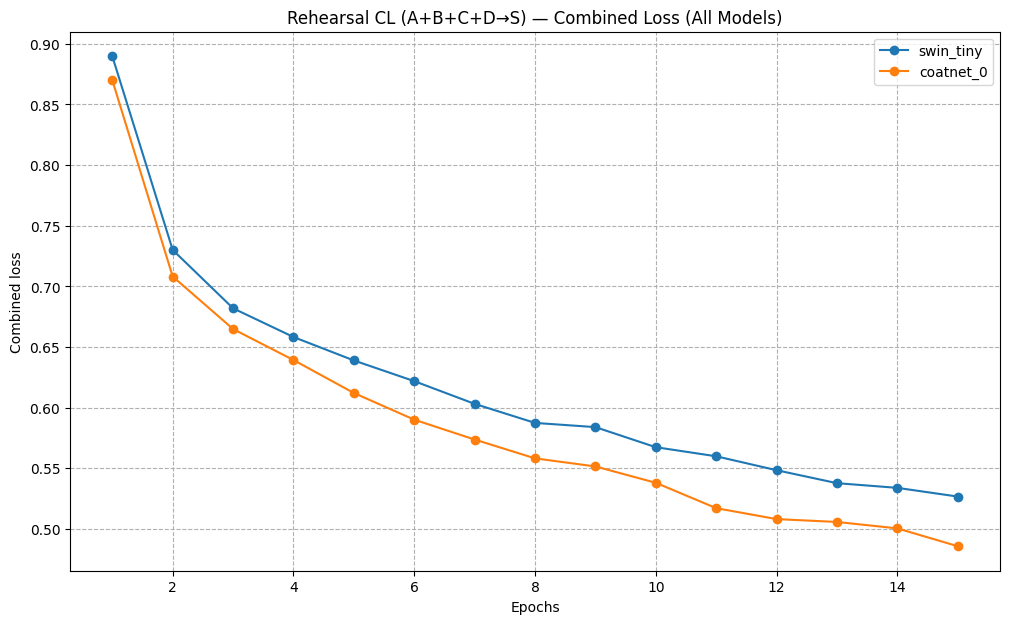

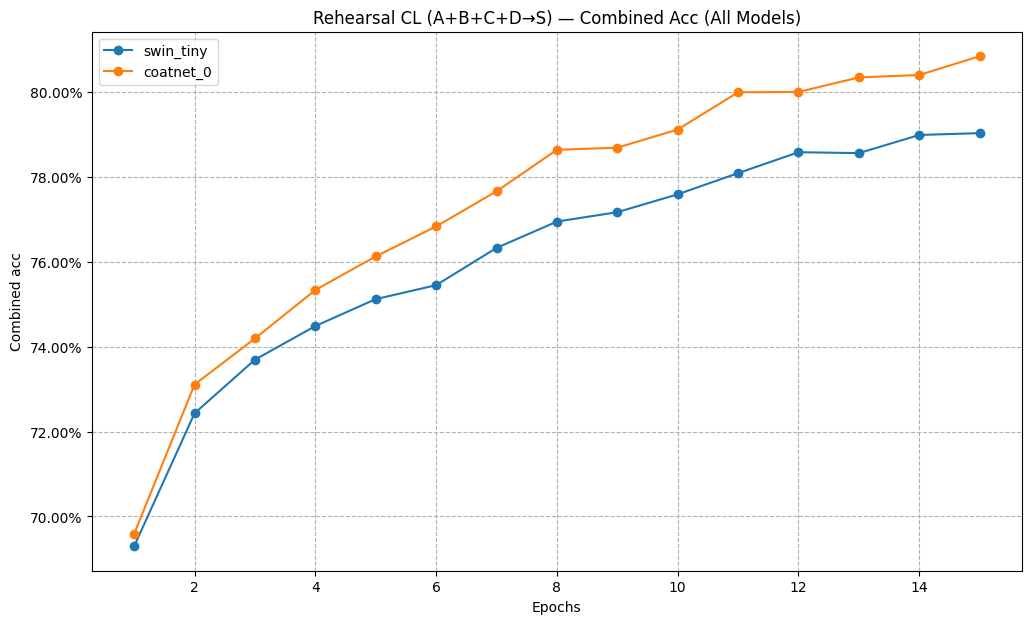

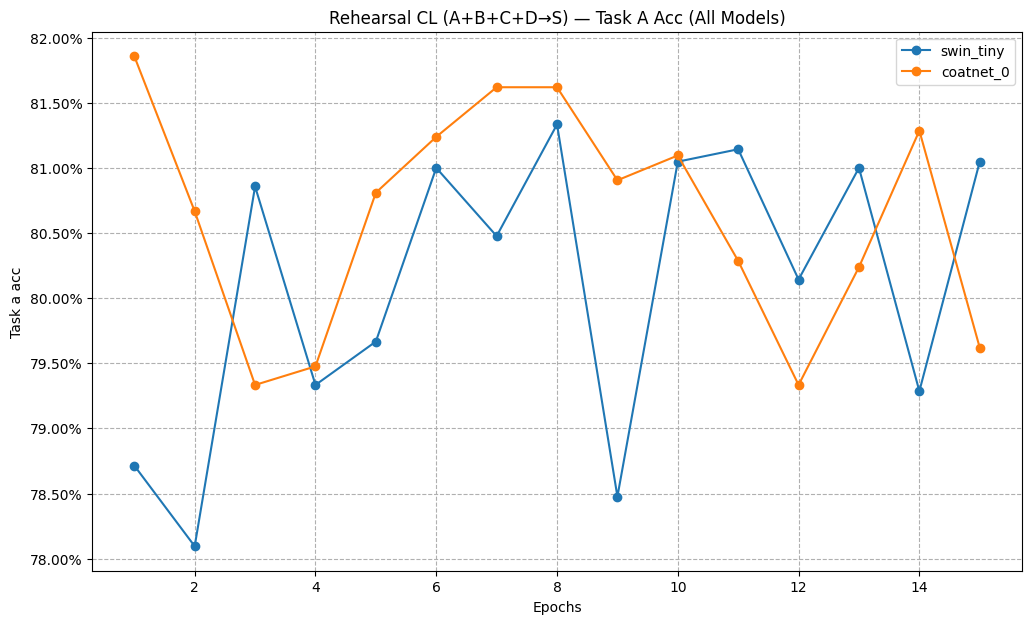

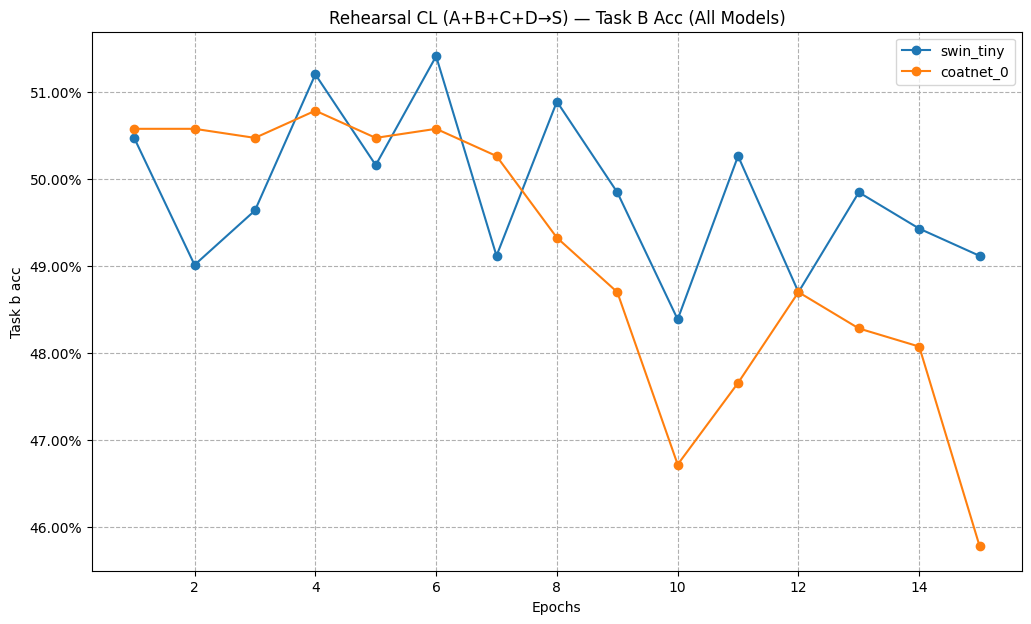

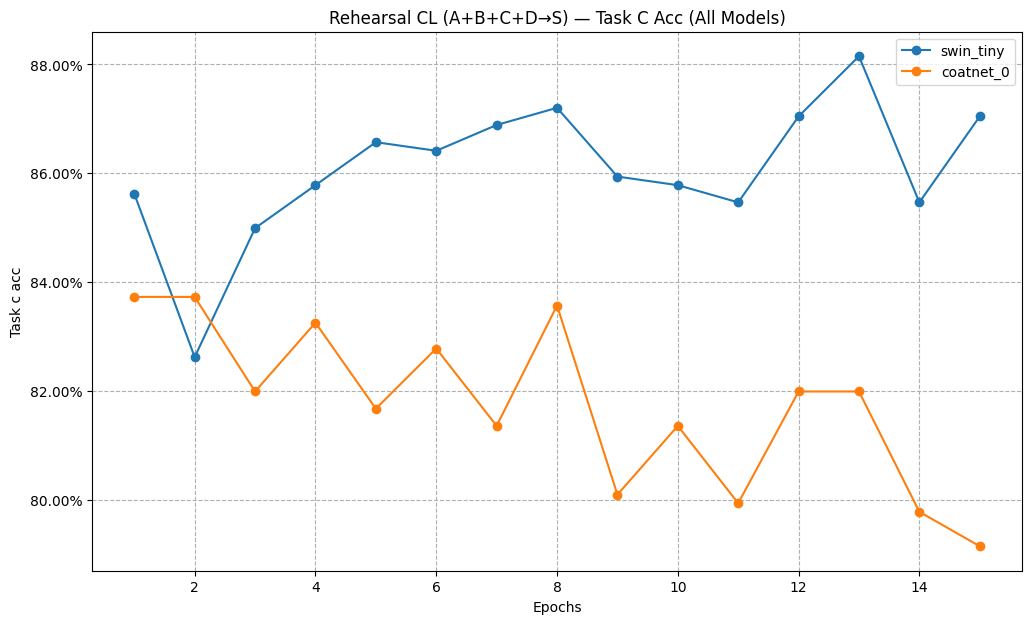

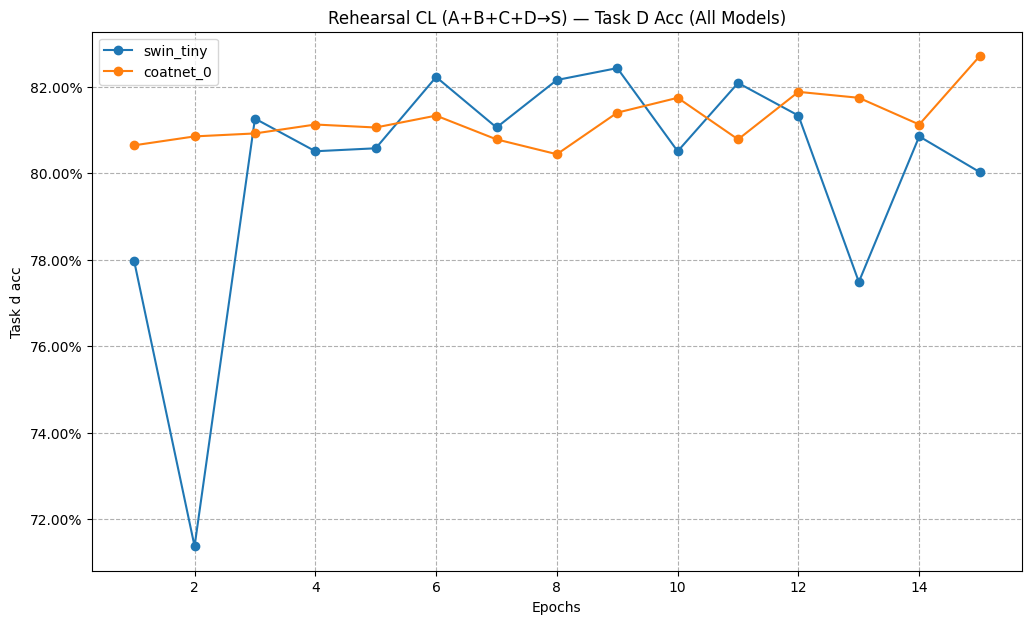

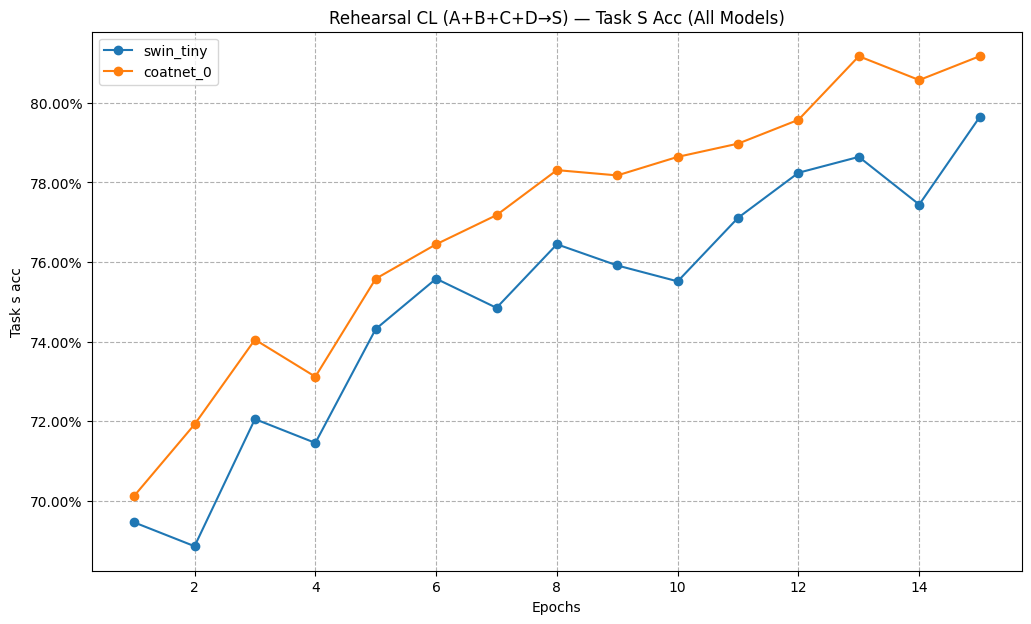


--- Naive: Comparative Plots (Catastrophic Forgetting) ---


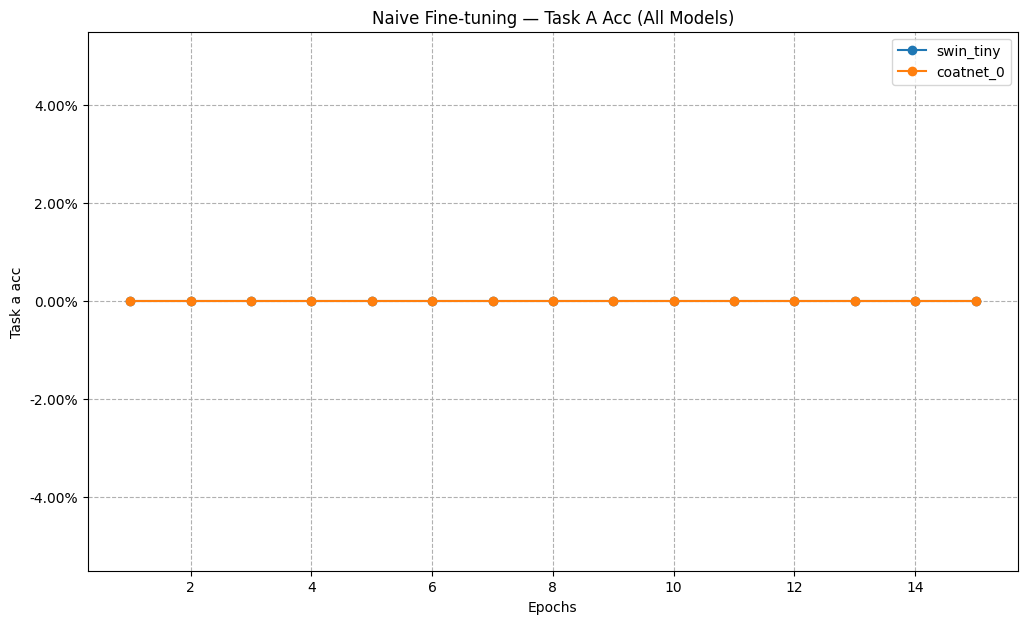

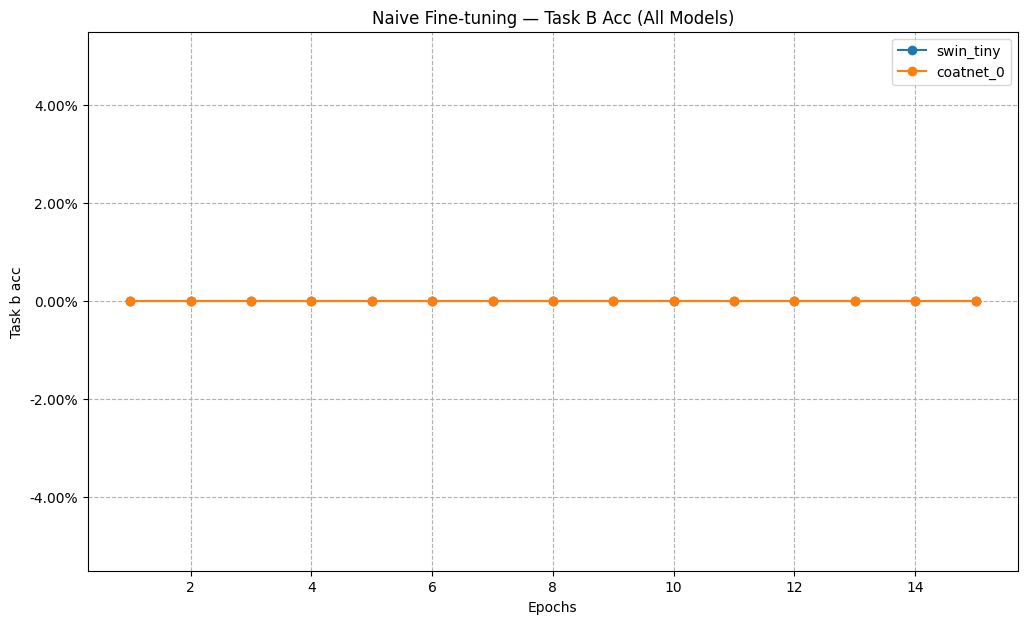

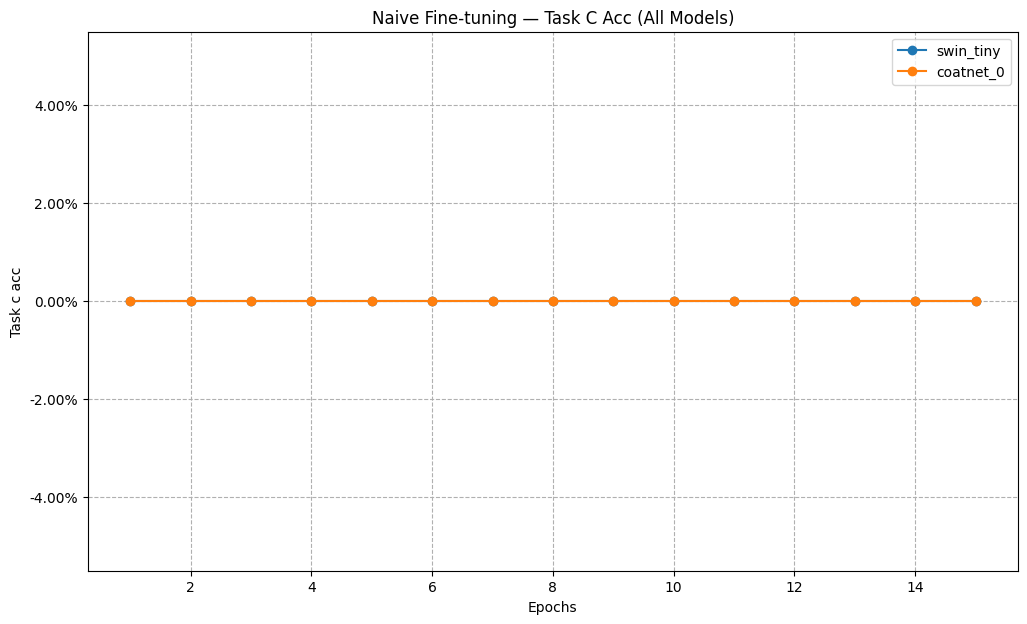

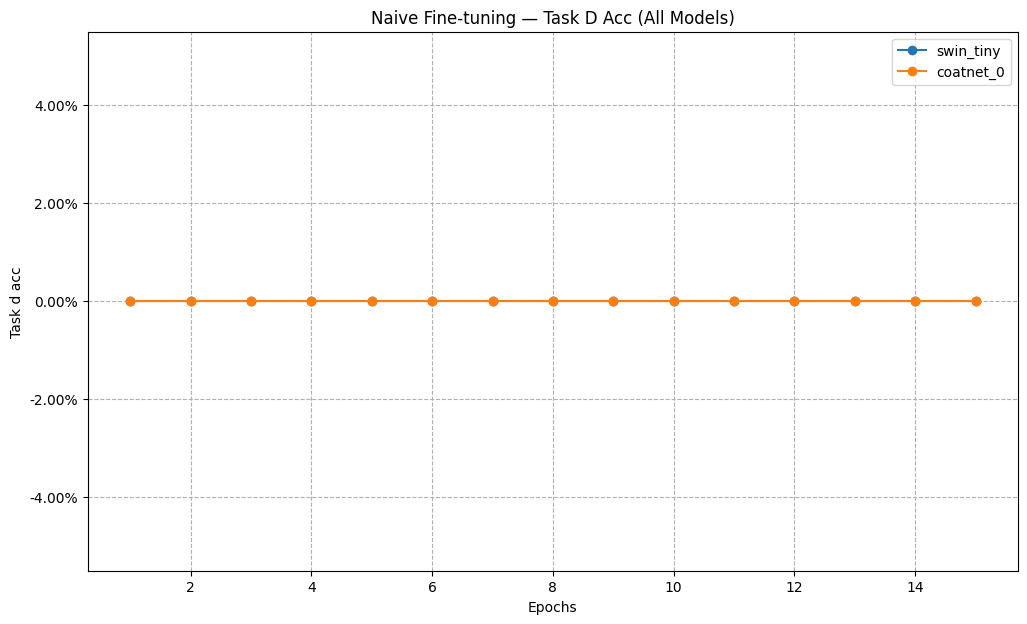

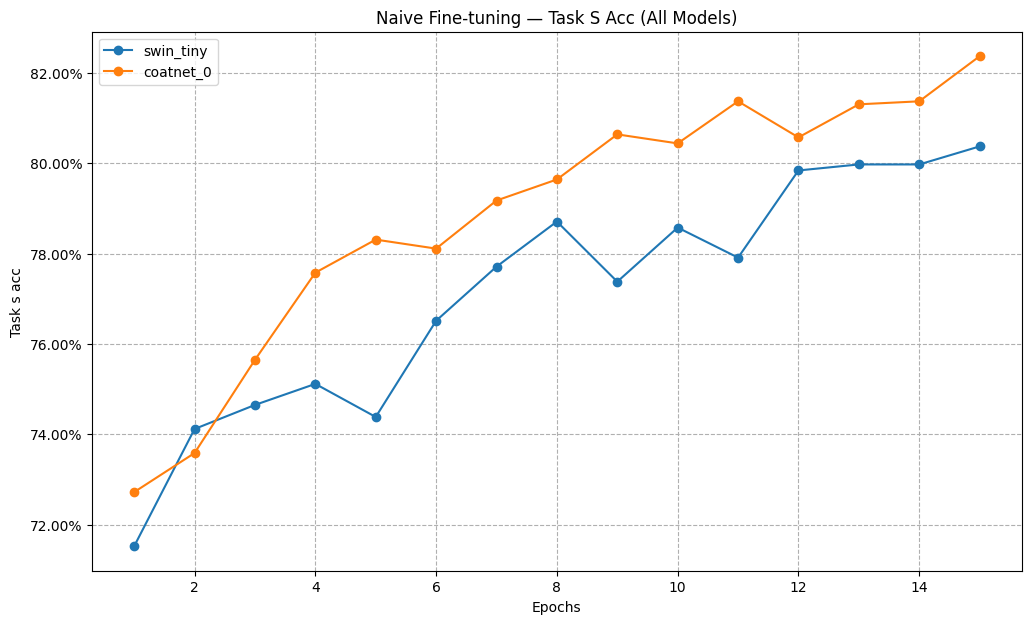


--- Per-Model Continuous Learning Curves ---


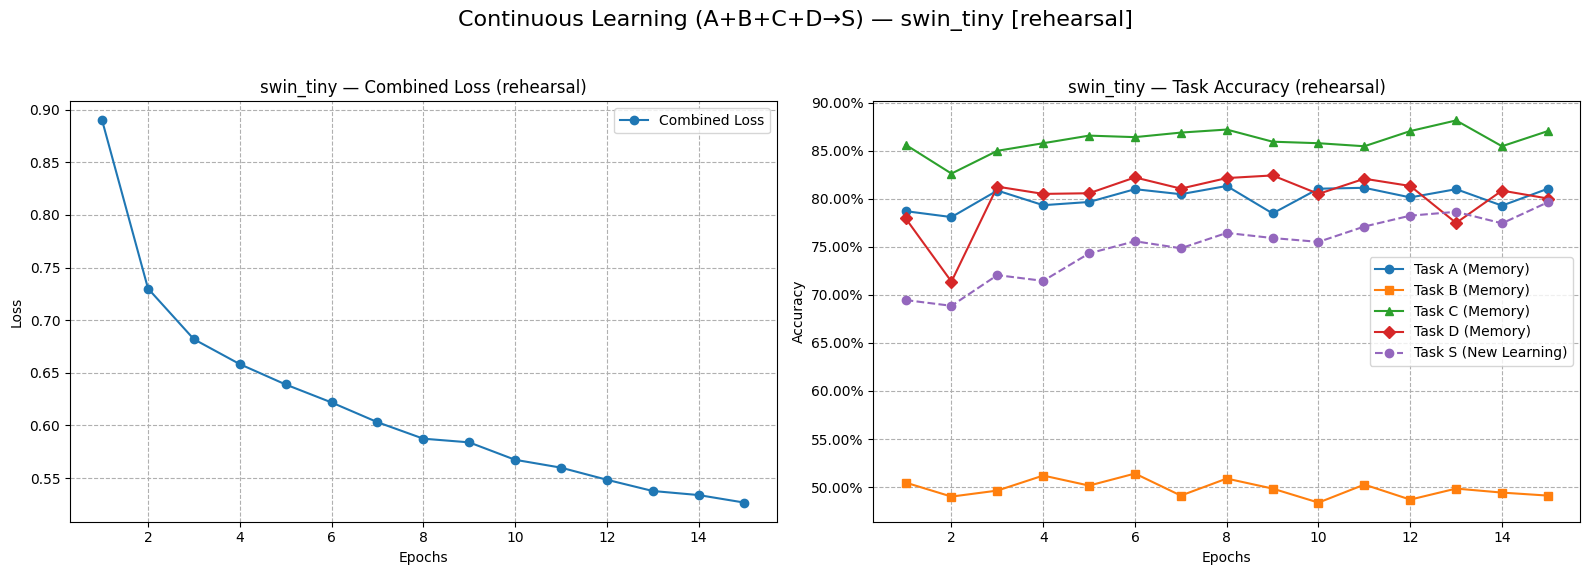

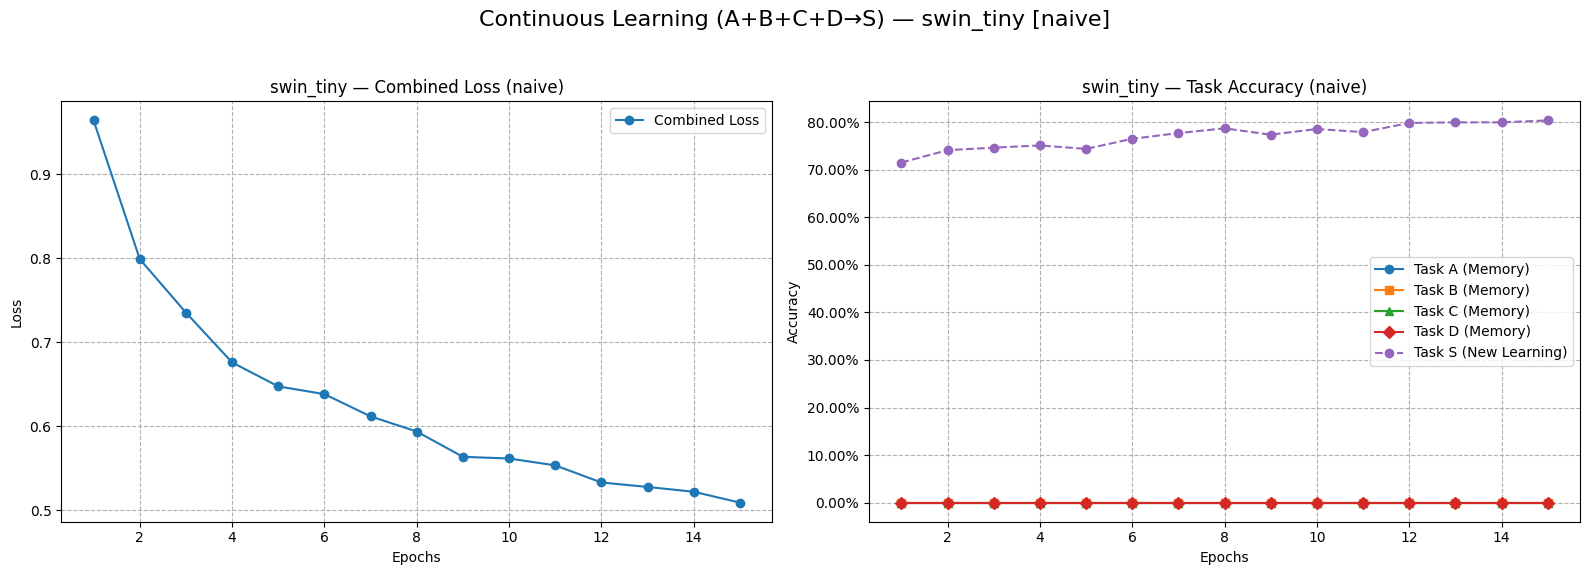

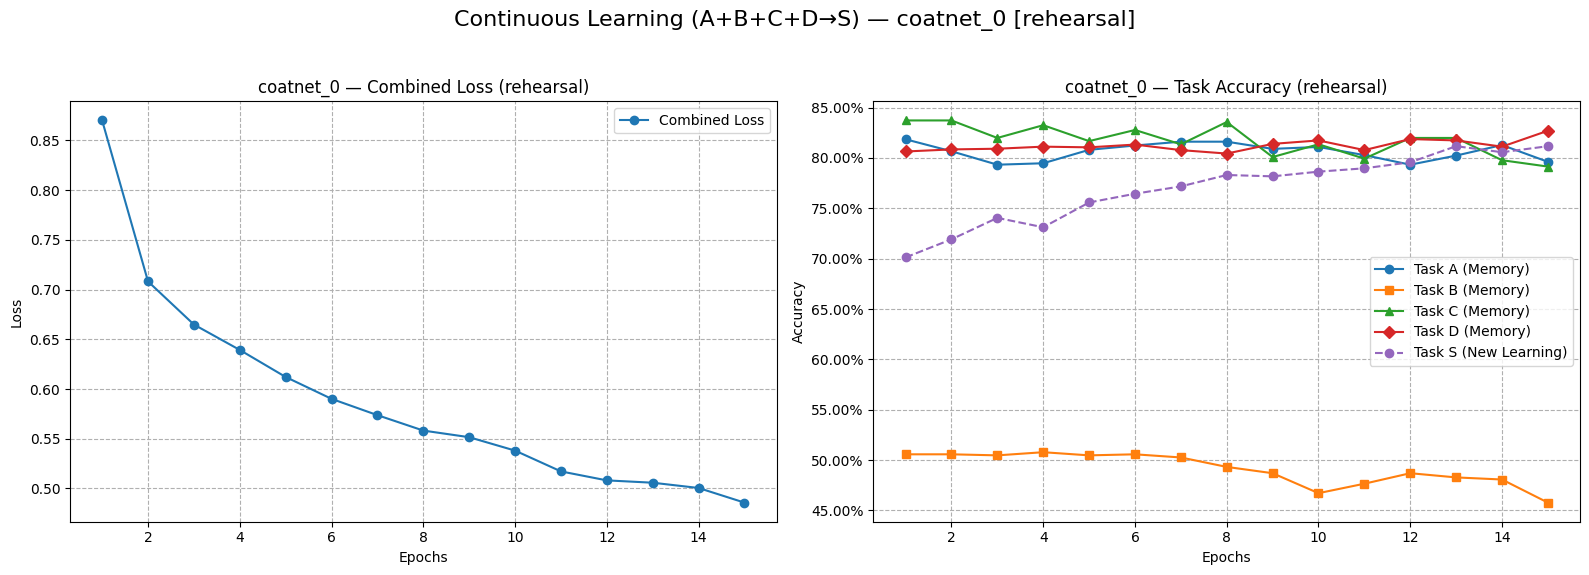

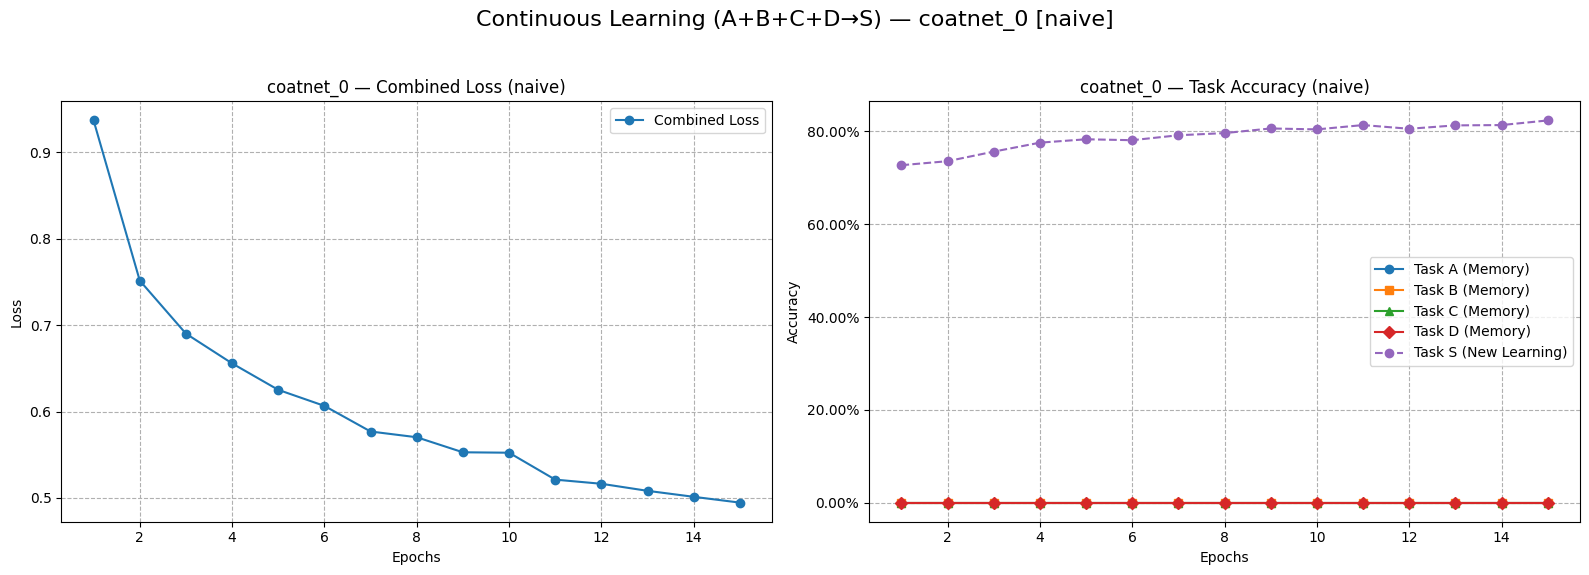


--- Detailed Test Set Performance per Model ---

Model: SWIN_TINY

--- Task A (Memory) ---
Classification Report (Task A (Memory)):
                      precision    recall  f1-score   support

            Cataract     0.9921    0.9524    0.9718       525
Diabetic Retinopathy     0.6901    0.6743    0.6821       525
            Glaucoma     0.9590    0.9352    0.9470       525
              Normal     0.6380    0.6914    0.6636       525

           micro avg     0.8141    0.8133    0.8137      2100
           macro avg     0.8198    0.8133    0.8161      2100
        weighted avg     0.8198    0.8133    0.8161      2100



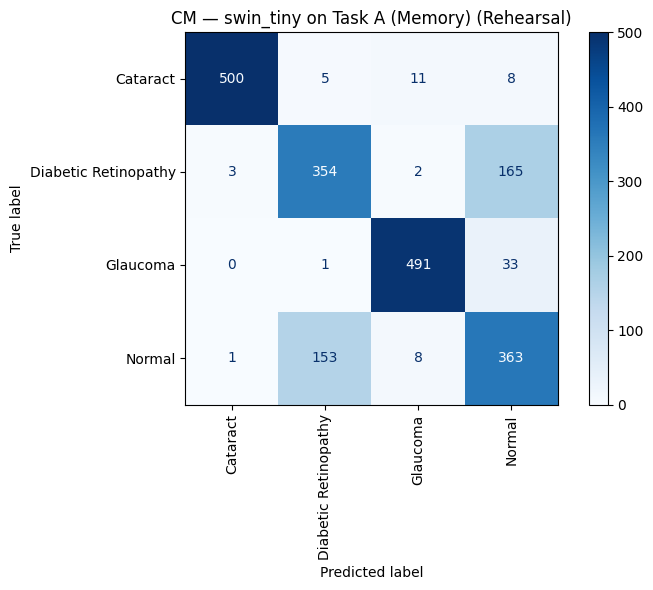


--- Task B (Memory) ---
Classification Report (Task B (Memory)):
                      precision    recall  f1-score   support

                 Amd     0.2500    0.1500    0.1875        40
            Cataract     0.6207    0.7500    0.6792        48
Diabetic Retinopathy     0.6340    0.3856    0.4795       319
            Glaucoma     0.4595    0.3333    0.3864        51
        Hypertension     0.0000    0.0000    0.0000        13
              Myopia     0.9412    0.8205    0.8767        39
              Normal     0.4629    0.8317    0.5948       315
               Other     0.2609    0.0896    0.1333       134

            accuracy                         0.5089       959
           macro avg     0.4536    0.4201    0.4172       959
        weighted avg     0.5036    0.5089    0.4715       959



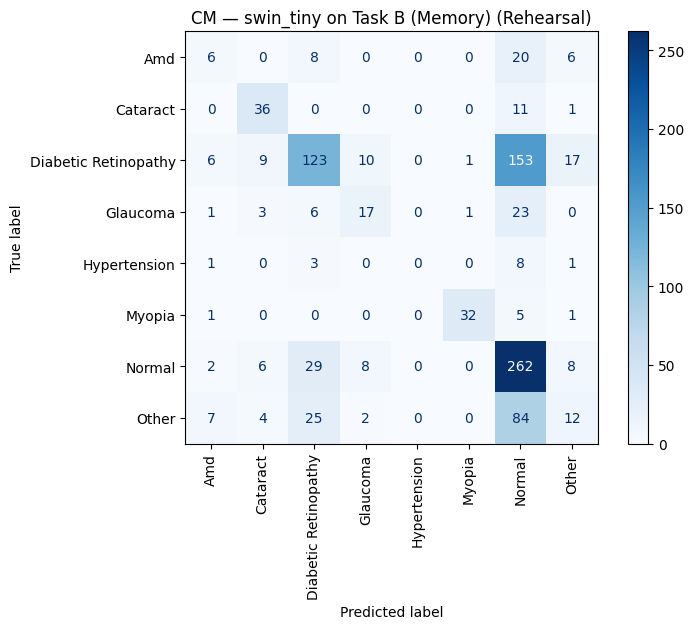


--- Task C (Memory) ---
Classification Report (Task C (Memory)):
                      precision    recall  f1-score   support

            Cataract     0.9080    0.9487    0.9279       156
Diabetic Retinopathy     0.9075    0.9515    0.9290       165
            Glaucoma     0.9106    0.7417    0.8175       151
              Normal     0.8084    0.8385    0.8232       161

           micro avg     0.8818    0.8720    0.8769       633
           macro avg     0.8836    0.8701    0.8744       633
        weighted avg     0.8831    0.8720    0.8752       633



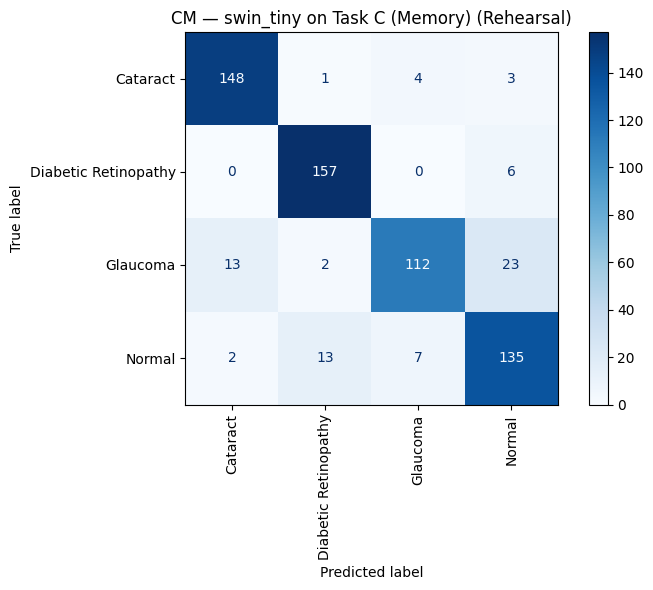


--- Task D (Memory) ---
Classification Report (Task D (Memory)):
              precision    recall  f1-score   support

      Normal     0.8366    0.9014    0.8678       943
    Glaucoma     0.7904    0.6751    0.7282       514

   micro avg     0.8227    0.8216    0.8221      1457
   macro avg     0.8135    0.7882    0.7980      1457
weighted avg     0.8203    0.8216    0.8186      1457



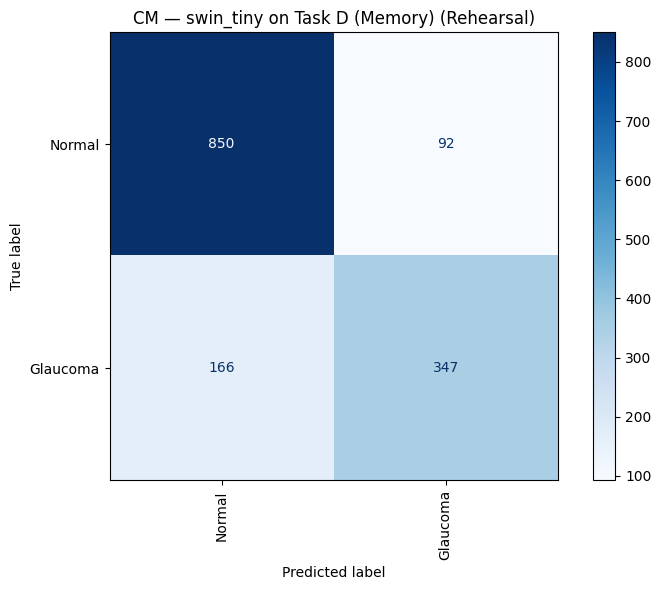


--- Task S (New Learning) ---
Classification Report (Task S (New Learning)):
                      precision    recall  f1-score   support

   Actinic Keratoses     0.3396    0.3673    0.3529        49
Basal Cell Carcinoma     0.7105    0.3506    0.4696        77
    Benign Keratosis     0.4639    0.4667    0.4653       165
      Dermatofibroma     0.5000    0.0588    0.1053        17
    Melanocytic Nevi     0.8547    0.9533    0.9013      1006
            Melanoma     0.5000    0.2994    0.3745       167
    Vascular Lesions     0.7727    0.7727    0.7727        22

            accuracy                         0.7645      1503
           macro avg     0.5916    0.4670    0.4917      1503
        weighted avg     0.7430    0.7645    0.7440      1503



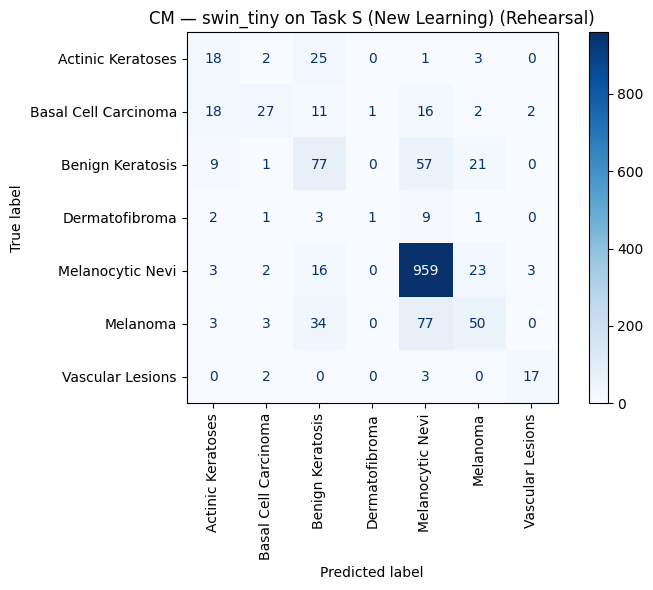


Model: COATNET_0

--- Task A (Memory) ---
Classification Report (Task A (Memory)):
                      precision    recall  f1-score   support

            Cataract     0.9897    0.9124    0.9495       525
Diabetic Retinopathy     0.7282    0.5410    0.6208       525
            Glaucoma     0.9501    0.9429    0.9465       525
              Normal     0.6100    0.8133    0.6971       525

           micro avg     0.8043    0.8024    0.8033      2100
           macro avg     0.8195    0.8024    0.8035      2100
        weighted avg     0.8195    0.8024    0.8035      2100



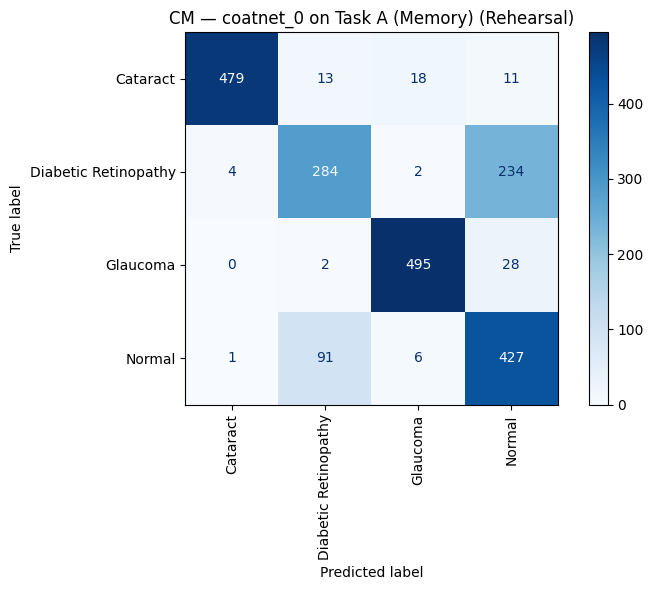


--- Task B (Memory) ---
Classification Report (Task B (Memory)):
                      precision    recall  f1-score   support

                 Amd     0.2963    0.2000    0.2388        40
            Cataract     0.7143    0.7292    0.7216        48
Diabetic Retinopathy     0.5275    0.4514    0.4865       319
            Glaucoma     0.4419    0.3725    0.4043        51
        Hypertension     0.0000    0.0000    0.0000        13
              Myopia     0.8750    0.7179    0.7887        39
              Normal     0.4592    0.6794    0.5480       315
               Other     0.2206    0.1119    0.1485       134

           micro avg     0.4833    0.4828    0.4830       959
           macro avg     0.4418    0.4078    0.4171       959
        weighted avg     0.4643    0.4828    0.4622       959



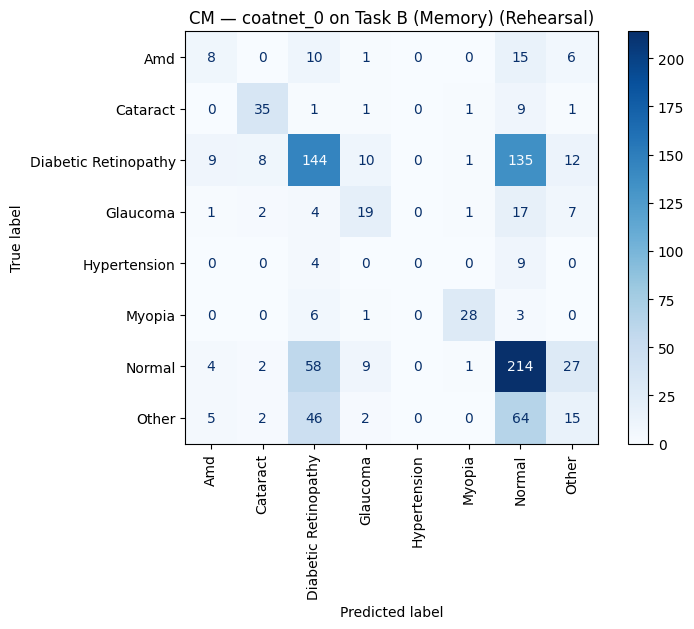


--- Task C (Memory) ---
Classification Report (Task C (Memory)):
                      precision    recall  f1-score   support

            Cataract     0.9408    0.9167    0.9286       156
Diabetic Retinopathy     0.8306    0.9212    0.8736       165
            Glaucoma     0.8898    0.6954    0.7807       151
              Normal     0.7391    0.7391    0.7391       161

           micro avg     0.8453    0.8199    0.8324       633
           macro avg     0.8501    0.8181    0.8305       633
        weighted avg     0.8486    0.8199    0.8308       633



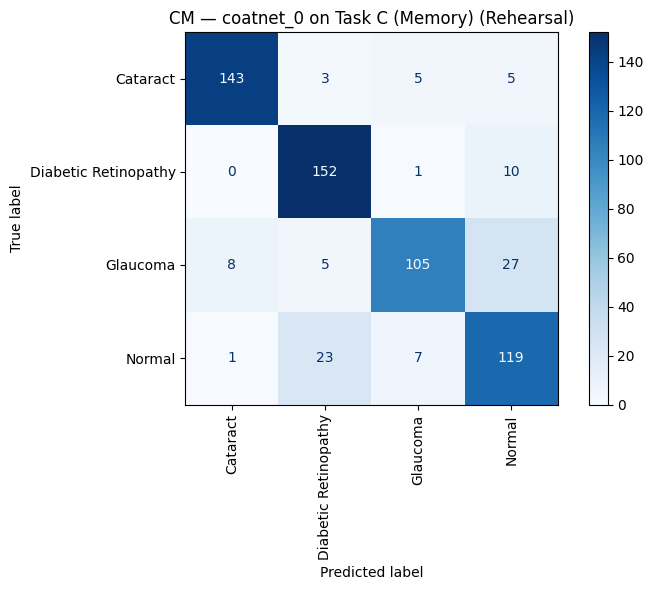


--- Task D (Memory) ---
Classification Report (Task D (Memory)):
              precision    recall  f1-score   support

      Normal     0.8145    0.9311    0.8689       943
    Glaucoma     0.8347    0.6089    0.7042       514

   micro avg     0.8197    0.8174    0.8186      1457
   macro avg     0.8246    0.7700    0.7865      1457
weighted avg     0.8216    0.8174    0.8108      1457



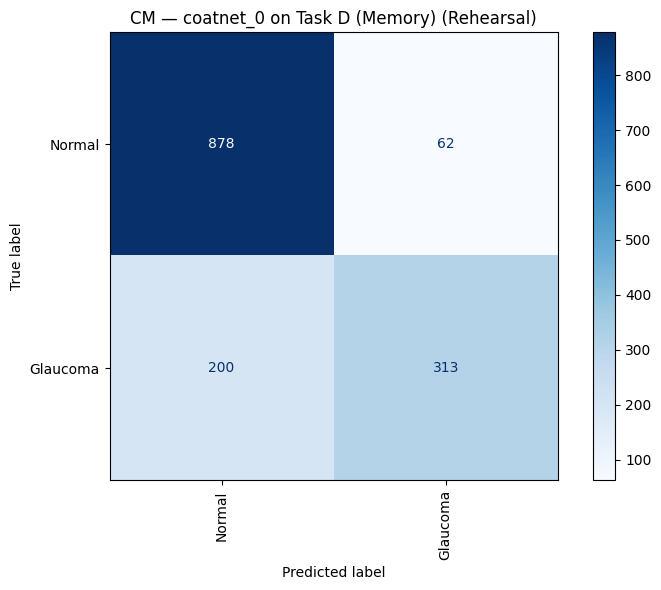


--- Task S (New Learning) ---
Classification Report (Task S (New Learning)):
                      precision    recall  f1-score   support

   Actinic Keratoses     0.5227    0.4694    0.4946        49
Basal Cell Carcinoma     0.6533    0.6364    0.6447        77
    Benign Keratosis     0.6812    0.5697    0.6205       165
      Dermatofibroma     0.6667    0.3529    0.4615        17
    Melanocytic Nevi     0.8793    0.9414    0.9093      1006
            Melanoma     0.6014    0.4970    0.5443       167
    Vascular Lesions     0.8182    0.8182    0.8182        22

            accuracy                         0.8117      1503
           macro avg     0.6890    0.6121    0.6419      1503
        weighted avg     0.8002    0.8117    0.8035      1503



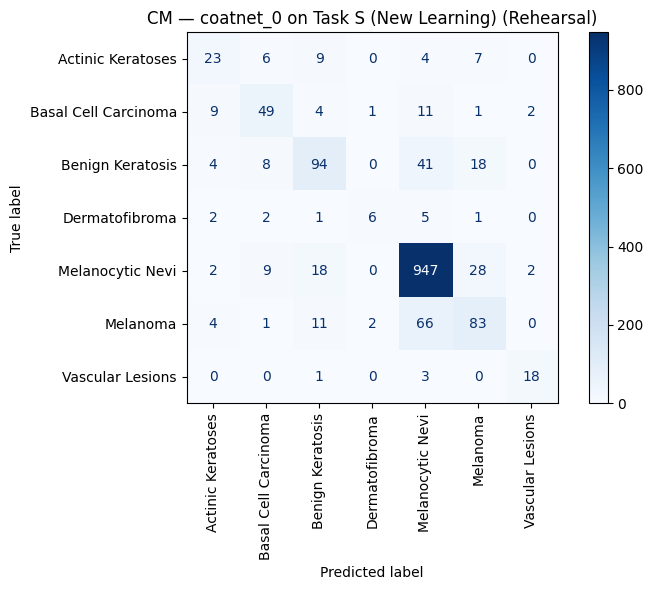


--- Task S Evaluation Complete ---


In [8]:
# ── Generate Plots ─────────────────────────────────────────────────────────────

print("\n--- Rehearsal: Comparative Plots ---")
for metric in ['combined_loss', 'combined_acc',
               'task_a_acc', 'task_b_acc', 'task_c_acc', 'task_d_acc', 'task_s_acc']:
    plot_metric_comparison(
        all_rehearsal_histories, metric,
        f"Rehearsal CL (A+B+C+D→S) — {metric.replace('_', ' ').title()} (All Models)"
    )

print("\n--- Naive: Comparative Plots (Catastrophic Forgetting) ---")
for metric in ['task_a_acc', 'task_b_acc', 'task_c_acc', 'task_d_acc', 'task_s_acc']:
    plot_metric_comparison(
        all_naive_histories, metric,
        f"Naive Fine-tuning — {metric.replace('_', ' ').title()} (All Models)"
    )

print("\n--- Per-Model Continuous Learning Curves ---")
for model_name in all_experiments_results:
    if model_name in all_rehearsal_histories:
        plot_cl_history_single_model(
            all_rehearsal_histories[model_name], model_name, "rehearsal")
    if model_name in all_naive_histories:
        plot_cl_history_single_model(
            all_naive_histories[model_name], model_name, "naive")

print("\n--- Detailed Test Set Performance per Model ---")
for model_name, results in all_experiments_results.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name.upper()}")
    print(f"{'='*60}")

    for task_key, task_label, task_classes in [
        ("rehearsal_task_a", "Task A (Memory)", [normalize_name(c) for c in TASK_A_CLASS_NAMES]),
        ("rehearsal_task_b", "Task B (Memory)", [normalize_name(c) for c in TASK_B_CLASS_NAMES]),
        ("rehearsal_task_c", "Task C (Memory)", [normalize_name(c) for c in TASK_C_CLASS_NAMES]),
        ("rehearsal_task_d", "Task D (Memory)", [normalize_name(c) for c in TASK_D_CLASS_NAMES]),
        ("rehearsal_task_s", "Task S (New Learning)", [normalize_name(c) for c in TASK_S_CLASS_NAMES]),
    ]:
        print(f"\n--- {task_label} ---")
        r = results['detailed_reports'][task_key]
        print(f"Classification Report ({task_label}):")
        print(r['classification_report_str'])
        plot_multiclass_confusion_matrix(
            r['confusion_matrix'], task_classes,
            title=f'CM — {model_name} on {task_label} (Rehearsal)')

print("\n--- Task S Evaluation Complete ---")

In [9]:
# ── Save Final Models ──────────────────────────────────────────────────────────
print("\n--- Saving Final Rehearsal Models ---")
for model_name, trained_model in all_final_trained_models.items():
    save_path = f"/kaggle/working/final_cl_model_taskS_{model_name}.pth"
    try:
        torch.save({
            'model_state_dict': trained_model.state_dict(),
            'all_class_names':  ALL_UNIQUE_CLASSES,
            'num_classes':      NUM_FINAL_CLASSES,
        }, save_path)
        print(f"  Saved: {save_path}")
    except Exception as e:
        print(f"  Error saving {model_name}: {e}")


--- Saving Final Rehearsal Models ---
  Saved: /kaggle/working/final_cl_model_taskS_swin_tiny.pth
  Saved: /kaggle/working/final_cl_model_taskS_coatnet_0.pth


In [10]:
# ── Package All Outputs ────────────────────────────────────────────────────────
print("\n--- Preparing Trained Models for Download ---")
output_zip_filename       = 'trained_models_taskS'
full_zip_path_without_ext = os.path.join('/kaggle/working/', output_zip_filename)
models_dir                = '/kaggle/working/'
pth_files_to_zip          = [f for f in os.listdir(models_dir) if f.endswith('.pth')]

if not pth_files_to_zip:
    print("WARNING: No .pth files found in /kaggle/working/ to zip.")
else:
    print("Found the following model files to zip:")
    for f in pth_files_to_zip:
        print(f"  - {f}")
    temp_zip_dir = os.path.join(models_dir, 'models_to_zip')
    os.makedirs(temp_zip_dir, exist_ok=True)
    for f in pth_files_to_zip:
        shutil.copy(os.path.join(models_dir, f), temp_zip_dir)
    print(f"\nCreating zip archive: {output_zip_filename}.zip ...")
    try:
        shutil.make_archive(full_zip_path_without_ext, 'zip', temp_zip_dir)
        zip_path = full_zip_path_without_ext + '.zip'
        if os.path.exists(zip_path):
            print(f"\nSUCCESS! Archive created at: {zip_path}")
            print("Download from the 'Output' section or use the link below:")
            display(FileLink(zip_path))
        else:
            print("ERROR: Zip was not created for an unknown reason.")
    except Exception as e:
        print(f"An error occurred during zipping: {e}")
    if os.path.exists(temp_zip_dir):
        shutil.rmtree(temp_zip_dir)


print("\n--- Preparing Results CSVs for Download ---")
results_zip_filename         = 'results_taskS'
full_results_zip_without_ext = os.path.join('/kaggle/working/', results_zip_filename)

if not os.path.exists(RESULTS_DIR) or not os.listdir(RESULTS_DIR):
    print("WARNING: No CSV results found.")
else:
    csv_files = os.listdir(RESULTS_DIR)
    print("Found the following results files to zip:")
    for f in csv_files:
        print(f"  - {f}")
    print(f"\nCreating zip archive: {results_zip_filename}.zip ...")
    try:
        shutil.make_archive(full_results_zip_without_ext, 'zip', RESULTS_DIR)
        results_zip_path = full_results_zip_without_ext + '.zip'
        if os.path.exists(results_zip_path):
            print(f"\nSUCCESS! Results archive created at: {results_zip_path}")
            print("Download from the 'Output' section or use the link below:")
            display(FileLink(results_zip_path))
        else:
            print("ERROR: Results zip was not created for an unknown reason.")
    except Exception as e:
        print(f"An error occurred during results zipping: {e}")


--- Preparing Trained Models for Download ---
Found the following model files to zip:
  - final_cl_model_taskS_coatnet_0.pth
  - best_cl_model_taskS_swin_tiny.pth
  - best_cl_model_taskS_coatnet_0.pth
  - final_cl_model_taskS_swin_tiny.pth

Creating zip archive: trained_models_taskS.zip ...

SUCCESS! Archive created at: /kaggle/working/trained_models_taskS.zip
Download from the 'Output' section or use the link below:


/kaggle/working/trained_models_taskS.zip


--- Preparing Results CSVs for Download ---
Found the following results files to zip:
  - final_metrics_taskS.csv
  - epoch_history_taskS.csv

Creating zip archive: results_taskS.zip ...

SUCCESS! Results archive created at: /kaggle/working/results_taskS.zip
Download from the 'Output' section or use the link below:


/kaggle/working/results_taskS.zip